João Pedro Banhato Pereira

joao.banhato@estudante.ufjf.br

# 1) Explorar os dados: apresente análises numéricas e/ou gráficos para mostrar os dados que você possui, como a base está dividida e quais relações você poderia explorar desses dados.

In [4]:
# bibliotecas utilizadas
import pandas as pd
import zipfile
from google.colab import drive
import matplotlib.pyplot as plt
import seaborn as sns
import random
import numpy as np

In [5]:
# importar dados do drive
drive.mount('/content/drive')
# caminho_zip = '/content/drive/My Drive/desafio/dataset - letras.zip'
caminho_zip = '/content/drive/My Drive/dataset - letras.zip'
# unzip nos dados:
with zipfile.ZipFile(caminho_zip, 'r') as zip_ref:
  zip_ref.extractall('.')

Mounted at /content/drive


In [6]:
# Vale ressaltar que o arquivo é relativamente grande. Então
# recomenda-se utilizar apenas trecho dele para testes de forma a não comprometer seu ritmo de programação.

# leitura das primeiras N linhas
caminho_dados = 'song_lyrics.csv'
df = pd.read_csv(caminho_dados, nrows=100)
# print(df.head())

In [ ]:
# obter numero total de linhas no arquivo original
!wc -l song_lyrics.csv

260569483 song_lyrics.csv


Portanto, observa-se uma quantidade estratosferica de dados: mais de 260 milhões de linhas, justamente por isso foi realizado um clipping para menos linhas para inicialmente apenas visualizar o que a base me oferece.

Posteriormente, caso necessario, pode ser aumentado de modo a observar melhor o que os dados de fato representam.

## 1.1) Brincando com os dados

### verificacoes iniciais

In [7]:
# funcao obtida para deixar prints importantes destacados
def print_cor(texto, cor='verde'):
    cores = {
        'vermelho': '\033[91m',
        'verde': '\033[92m',
        'amarelo': '\033[93m',
        'azul': '\033[94m',
    }
    reset = '\033[0m'
    print(f"{cores.get(cor, '')}{texto}{reset}")

Antes de qualquer coisa: vamos remover duplicatas, caso haja alguma dentro da database:

In [ ]:
# removendo duplicatas:
df.drop_duplicates(subset=None, inplace=True)

Agora vamos verificar as colunas presentes:

In [ ]:
# dimensionalidade:
print_cor(f"linhas, colunas: {df.shape}")
print_cor("\nPrimeiras linhas:")
display(df.head())

# colunas
print_cor("colunas:")
df.info()

linhas, colunas: (10000, 11)

Primeiras linhas:


,title,tag,artist,year,views,features,lyrics,id,language_cld3,language_ft,language
0,Killa Cam,rap,Cam'ron,2004,173166,"{""Cam\\'ron"",""Opera Steve""}","[Chorus: Opera Steve & Cam'ron]\nKilla Cam, Ki...",1,en,en,en
1,Can I Live,rap,JAY-Z,1996,468624,{},"[Produced by Irv Gotti]\n\n[Intro]\nYeah, hah,...",3,en,en,en
2,Forgive Me Father,rap,Fabolous,2003,4743,{},Maybe cause I'm eatin\nAnd these bastards fien...,4,en,en,en
3,Down and Out,rap,Cam'ron,2004,144404,"{""Cam\\'ron"",""Kanye West"",""Syleena Johnson""}",[Produced by Kanye West and Brian Miller]\n\n[...,5,en,en,en
4,Fly In,rap,Lil Wayne,2005,78271,{},"[Intro]\nSo they ask me\n""Young boy\nWhat you ...",6,en,en,en


colunas:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 11 columns):
 #   Column         Non-Null Count  Dtype 
---  ------         --------------  ----- 
 0   title          10000 non-null  object
 1   tag            10000 non-null  object
 2   artist         10000 non-null  object
 3   year           10000 non-null  int64 
 4   views          10000 non-null  int64 
 5   features       10000 non-null  object
 6   lyrics         10000 non-null  object
 7   id             10000 non-null  int64 
 8   language_cld3  9987 non-null   object
 9   language_ft    9992 non-null   object
 10  language       9978 non-null   object
dtypes: int64(3), object(8)
memory usage: 859.5+ KB


Observamos, inicialmente, que há 11 atributos presentes na database para cada amostra. São eles, seus tipos e uma pequena descrição, respectivamente:

- title: object -> título da música
- tag: object -> gênero da música
- artist: object -> artista da música
- year: int64 ->  ano de produção da música
- views: int64 -> número de visualizações da amostra
- features: object -> artistas envolvidos na produção da música
- lyrics: object -> letra da música
- id: int64 ->  id da amostra
- language_cld3: object -> resultado da biblioteca CLD3 (Compact Language Detector 3) quanto ao idioma da letra
- language_ft: object -> resultado do modelo FastTexto para o idioma da letra
- language: object -> provavelmente o idioma em comum das 2 colunas anteriores (visto que há valores nulos neste atributo)

In [ ]:
# display nas instancias nao preenchidas:
print_cor("instancias nao preenchidas:")
display(df[df.isnull().any(axis=1)])

instancias nao preenchidas:


,title,tag,artist,year,views,features,lyrics,id,language_cld3,language_ft,language
137,Combination Pizza Hut and Taco Bell,rap,Das Racist,2008,71968,{},[Intro: Kool A.D.]\nHa\nHa-ha\nHa\nHa-ha\nHa\n...,143,NaN,en,NaN
357,Watagatapitusberry Remix,rap,Pitbull,2010,23034,"{""Lil Jon"",Sensato,""Black Jonas Point"",""El Cata""}","[Letra de ""Watagatapitusberry (Remix)"" ft. Sen...",352,es,NaN,NaN
1216,Voila,pop,Radio Killer,2009,1567,{},"Voila, la la la c'est la\nVoila, la la la c'es...",1201,en,fr,NaN
1359,Im Paris Hilton,rap,Lil B,2010,20376,{},"[Intro]\nOhmigod, ohmigod, ohmigod, Based God,...",1332,NaN,en,NaN
1558,I Wanna Be Sedated,rock,Ramones,1978,90801,{},[Chorus]\nTwenty-twenty-twenty four hours to g...,1537,NaN,en,NaN
1652,The Reed Beshno as Ney.. from Masnavi,rap,Rumi,2010,8303,{},Beshno az ney chon hekaayat mikonad\nAz jodaay...,1633,so,NaN,NaN
2376,Faramarz Aslani - Age Ye Rooz Romanized,pop,Genius Romanizations,1973,93200,{},[Verse 1]\nAge ye rooz beri safar\nBeri ze pis...,2372,hi,NaN,NaN
2603,Ride On Me,rap,Blade Icewood,2005,8581,{},"[ Talking ]\nUh, Yea Heard These Niggas Wanted...",2606,en,NaN,NaN
2996,Hood Politics,rap,Jeezy,2010,5728,{},"Hood politics, yeah\nHood politics, yeah\nHood...",3010,NaN,en,NaN
3046,Sit Down People,rap,Das Racist,2010,2405,"{""Quincy Jones"",Dapwell}","Robert Mugabe! (Sit down, man...)\nCarlos Menc...",3151,NaN,en,NaN


Aparentemente quando nao identifica a linguagem em uma das colunas, a resultante fica NaN tambem. Assim como nos casos em que nenhum idioma é identificado.

Creio que pode ser feito um tratamento aqui da seguinte maneira: se uma coluna idetificou um idioma a resultante pode ser ele, mesmo que a outra seja NaN.

Mas caso os idiomas sejam distintos, a instância será removida.

Dessa forma, podemos reduzir a dimensionalidade da base de dados ao remover as colunas ```language_cld3``` e ```language_ft```

In [8]:
def tratamento_language(row):
    if pd.isna(row['language']):
        if not pd.isna(row['language_cld3']) and not pd.isna(row['language_ft']):
            if row['language_cld3'] != row['language_ft']: # se ambos diferentes, sera removida
                return np.nan
            else:
                return row['language_cld3'] # como sao iguais, tanto faz qual retornar
        elif not pd.isna(row['language_cld3']):
            return row['language_cld3']
        elif not pd.isna(row['language_ft']):
            return row['language_ft']
    return row['language']

In [ ]:
df['language'] = df.apply(tratamento_language, axis=1)
df.dropna(subset=['language'], inplace=True)

print_cor("tratamento de linguagem e remove amostras com idiomas com conflito:")
print_cor(f"Dimensionalidade após tratamento: {df.shape}")
print_cor("Instancias nao preenchidas após tratamento:")
display(df[df.isnull().any(axis=1)])

tratamento de linguagem e remove amostras com idiomas com conflito:
Dimensionalidade após tratamento: (9997, 11)
Instancias nao preenchidas após tratamento:


,title,tag,artist,year,views,features,lyrics,id,language_cld3,language_ft,language
137,Combination Pizza Hut and Taco Bell,rap,Das Racist,2008,71968,{},[Intro: Kool A.D.]\nHa\nHa-ha\nHa\nHa-ha\nHa\n...,143,NaN,en,en
357,Watagatapitusberry Remix,rap,Pitbull,2010,23034,"{""Lil Jon"",Sensato,""Black Jonas Point"",""El Cata""}","[Letra de ""Watagatapitusberry (Remix)"" ft. Sen...",352,es,NaN,es
1359,Im Paris Hilton,rap,Lil B,2010,20376,{},"[Intro]\nOhmigod, ohmigod, ohmigod, Based God,...",1332,NaN,en,en
1558,I Wanna Be Sedated,rock,Ramones,1978,90801,{},[Chorus]\nTwenty-twenty-twenty four hours to g...,1537,NaN,en,en
1652,The Reed Beshno as Ney.. from Masnavi,rap,Rumi,2010,8303,{},Beshno az ney chon hekaayat mikonad\nAz jodaay...,1633,so,NaN,so
2376,Faramarz Aslani - Age Ye Rooz Romanized,pop,Genius Romanizations,1973,93200,{},[Verse 1]\nAge ye rooz beri safar\nBeri ze pis...,2372,hi,NaN,hi
2603,Ride On Me,rap,Blade Icewood,2005,8581,{},"[ Talking ]\nUh, Yea Heard These Niggas Wanted...",2606,en,NaN,en
2996,Hood Politics,rap,Jeezy,2010,5728,{},"Hood politics, yeah\nHood politics, yeah\nHood...",3010,NaN,en,en
3046,Sit Down People,rap,Das Racist,2010,2405,"{""Quincy Jones"",Dapwell}","Robert Mugabe! (Sit down, man...)\nCarlos Menc...",3151,NaN,en,en
3824,Aggressive アグレッシ部,rap,KREVA,2011,4404,{},(see below for Romaji and Kanji because it obv...,3899,NaN,en,en


In [ ]:
# remove colunas language obsoletas:
df.drop(columns=['language_cld3', 'language_ft'], inplace=True)
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 9997 entries, 0 to 9999
Data columns (total 9 columns):
 #   Column    Non-Null Count  Dtype 
---  ------    --------------  ----- 
 0   title     9997 non-null   object
 1   tag       9997 non-null   object
 2   artist    9997 non-null   object
 3   year      9997 non-null   int64 
 4   views     9997 non-null   int64 
 5   features  9997 non-null   object
 6   lyrics    9997 non-null   object
 7   id        9997 non-null   int64 
 8   language  9997 non-null   object
dtypes: int64(3), object(6)
memory usage: 781.0+ KB


Agora, vamos remover as amostras com alguma variável chave nula:

In [ ]:
# removendo as amostras com variavel chave nula (title, tag, artist, year, views, lyrics):
df.dropna(subset=['title', 'tag', 'artist', 'year', 'views', 'lyrics'], inplace=True)
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 9997 entries, 0 to 9999
Data columns (total 9 columns):
 #   Column    Non-Null Count  Dtype 
---  ------    --------------  ----- 
 0   title     9997 non-null   object
 1   tag       9997 non-null   object
 2   artist    9997 non-null   object
 3   year      9997 non-null   int64 
 4   views     9997 non-null   int64 
 5   features  9997 non-null   object
 6   lyrics    9997 non-null   object
 7   id        9997 non-null   int64 
 8   language  9997 non-null   object
dtypes: int64(3), object(6)
memory usage: 781.0+ KB


```language``` já tratamos.

 ```features```, caso esteja vazia, vamos transformar em um chaves vazias.

In [ ]:
# features, se vazia, vira chaves vazia:
df['features'] = df['features'].fillna('{}')

Vamos também remover a colunas de id, já que não tem utilidade neste trabalho

In [ ]:
# remove id
df.drop(columns=['id'], inplace=True)

Vamos agora a uma descricao mais detalhada do dataset:

In [ ]:
# descricao com df.describe()
print_cor("descricao:")
display(df.describe(include='all'))

# nulos
print_cor("nulos:")
print(df.isnull().sum())

descricao:


,title,tag,artist,year,views,features,lyrics,language
count,9997,9997,9997,9997.000000,9.997000e+03,9997,9997,9997
unique,9340,6,1526,NaN,NaN,2768,9997,8
top,Intro,rap,2Pac,NaN,NaN,{},[Intro: Bizzy Bone]\nRest in peace Karlos Sham...,en
freq,16,9478,262,NaN,NaN,5715,1,9794
mean,NaN,NaN,NaN,2002.837451,7.305353e+04,NaN,NaN,NaN
std,NaN,NaN,NaN,23.259099,2.522294e+05,NaN,NaN,NaN
min,NaN,NaN,NaN,2.000000,3.000000e+00,NaN,NaN,NaN
25%,NaN,NaN,NaN,1999.000000,9.680000e+02,NaN,NaN,NaN
50%,NaN,NaN,NaN,2005.000000,6.693000e+03,NaN,NaN,NaN
75%,NaN,NaN,NaN,2009.000000,4.192900e+04,NaN,NaN,NaN


nulos:
title       0
tag         0
artist      0
year        0
views       0
features    0
lyrics      0
language    0
dtype: int64


Aqui ja temos algumas infos importantes. Destacam-se:
- temos alguns titulos nao unicos, o que pode (ou nao) ser duplicata
- temos um valor de tags unicas relativamente baixo, o que pode ser pensado em transformá-la em colunas booleanas para cada gênero, se for necessario futuramente
- há muitos artistas repetidos
- a maior parte das instancias não possuem features
- views e year, como sao atributos numericos, serao normalizados futuramente
- lyrics deverá ser tratado quanto a caracteres especiais, quebras de linhas, etc

In [ ]:
# verificar as tags unicas:
print_cor("tags unicas:")
print(df['tag'].unique())

tags unicas:
['rap' 'rb' 'rock' 'pop' 'misc' 'country']


Vamos agora conferir as duplicatas de titulo

In [ ]:
# contagem de duplicatas
titulos_iguais = df['title'].value_counts()
titulos_iguais = titulos_iguais[titulos_iguais > 1]
print_cor("titulos repetidos:")
print(titulos_iguais)

titulos repetidos:
title
Intro         16
Get Down       6
Fire           6
Salute         5
Dont Stop      5
              ..
Dreamer        2
Trees          2
Colors         2
Close Call     2
Destiny        2
Name: count, Length: 482, dtype: int64


In [9]:
# ver se de fato sao cópias
def verifica_titulo_duplicatas(df):
  copias_titulo_true = df.duplicated(subset=['title', 'artist', 'year'])
  print_cor(f"copias reais (titulo, artista, ano): {copias_titulo_true.sum()}")
  print(df[copias_titulo_true])
  # remove a duplicata:
  df.drop_duplicates(subset=['title', 'artist', 'year'], keep='first', inplace=True)


In [ ]:
verifica_titulo_duplicatas(df)

De fato, para essa pequena amostra, eram apenas titulos semelhantes, mas a análise permanece para os dados maiores:

Vamos nos ater a apenas 5 gêneros: o gênero ```misc``` será removido, uma vez que contém amostras como poemas, documentos, etc.

Mesmo que haja letras de músicas de fato, de modo a deixarmos apenas as amostras puramente musicais, serão removidas todas as instâncias desse gênero.

In [ ]:
# remover amostras miscelaneas
df = df[df['tag'] != 'misc']

Vamos também remover aquelas amostras com número de views igual a 0:

In [ ]:
# removendo amostras com views zeradas:
df = df[df['views'] > 0]

Portanto, antes de passarmos para uma amostragem maior, vamos criar uma funcao geral de limpeza dos dados com as informacoes coletadas nessa primeira etapa de modo a replicarmos na fase seguinte:

In [10]:
def limpeza_dados(df):
  # removendo duplicatas:
  df.drop_duplicates(subset=None, inplace=True)
  # limpeza idiomas
  df['language'] = df.apply(tratamento_language, axis=1)
  df.dropna(subset=['language'], inplace=True)
  # remove colunas language obsoletas:
  if 'language_cld3' in df.columns and 'language_ft' in df.columns:
    df.drop(columns=['language_cld3', 'language_ft'], inplace=True)
  # removendo as amostras com variavel chave nula (title, tag, artist, year, views, lyrics):
  df.dropna(subset=['title', 'tag', 'artist', 'year', 'views', 'lyrics'], inplace=True)
  df.info()
  # features, se vazia, vira chaves vazia:
  df['features'] = df['features'].fillna('{}')
  # remove id
  if 'id' in df.columns:
    df.drop(columns=['id'], inplace=True)
  # trata das copias de titulo, ano, artista
  verifica_titulo_duplicatas(df)
  # removendo genero misc
  df = df[df['tag'] != 'misc']
  # removendo amostras com views zeradas:
  df = df[df['views'] > 0]

  return df

### usando numero de amostras maior:

In [ ]:
df_maior = pd.read_csv(caminho_dados, nrows=1000000)

In [ ]:
df_maior = limpeza_dados(df_maior)

In [ ]:
# descricao com df.describe()
print_cor("descricao:")
display(df_maior.describe(include='all'))

# nulos
print_cor("nulos:")
print(df_maior.isnull().sum())

Agora, para um numero de amostras maior, percebe-se:

- é possivel haver duplicata de menos variaveis (que foi tratado)
- os valores de 'views' e 'year' parecem conter outliers (valores mt fora do normal, mt pequenos, no caso): pode haver uma filtragem

### verificar anos anormais

In [ ]:
ano_corte = 1900
anos_anormais = df_maior[df_maior['year'] < ano_corte]
print(anos_anormais[['title', 'artist', 'year']])
print(f"\nTotal de linhas com ano < {ano_corte}: {len(anos_anormais)}")

                                         title                   artist  year
1360                        The Severed Garden                The Doors  1878
1472                    Im Nobody Who Are You?          Emily Dickinson  1891
1567                                Kubla Khan  Samuel Taylor Coleridge  1816
1571             The Mower Against The Gardens           Andrew Marvell  1681
1640                                 The Tyger            William Blake  1789
...                                        ...                      ...   ...
981628  Blick Ich Umher In Diesem Edlen Kreise           Richard Wagner  1845
984933                      I Want What I Want                  Blog 27   205
989415                          Sioux City Sue              Bing Crosby     2
989858                                 Hostias  Wolfgang Amadeus Mozart  1792
998012              Cavatina - Se Vuol ballare  Wolfgang Amadeus Mozart  1786

[13964 rows x 3 columns]

Total de linhas com ano < 1900: 13964

A maioria das instâncias presentes acima, de fato, representa obras (poemas, músicas, registros escritos, etc) correspondentes à epoca mencionada.

Entretanto, encontrei um dado incorreto: 'The Severed Garden', de 'The Doors', em 1878. Na verdade, verificando na internet, percebi que foi um erro de escrita, pq era pra ser 1978. Mesmo sendo apenas 1 dado dentre 18 (0.05%), pode ser pensado algum tipo de estratégia, posteriormente, para verificar esses outliers dentro de um contexto do autor: por exemplo, verificar a média de ano de publicacao da banda The Doors, caso algum esteja muito fora, cortar o dado.

In [11]:
def remove_anos_anormais(df_maior):
  anos_anormais = df_maior[df_maior['year'] < 1900]
  artistas_suspeitos = anos_anormais['artist'].unique() # com anos anormais

  # media e std dev desses artistas, porem nos anos validos deles
  #(pra depois comparar com invalidos)
  artistas_validos = df_maior[(df_maior['artist'].isin(artistas_suspeitos)) & (df_maior['year'] >= 1900)]
  artistas_stats = artistas_validos.groupby('artist')['year'].agg(['mean', 'std']).reset_index()
  print(artistas_stats)

  def ano_incorreto(row):
      if row['artist'] not in artistas_suspeitos:
          return False
      artist_data = artistas_stats[artistas_stats['artist'] == row['artist']]
      if artist_data.empty:
          return False
      media = artist_data['mean'].values[0]
      desvio = artist_data['std'].values[0]
      if desvio == 0 or np.isnan(desvio):
          return False
      return abs(row['year'] - media) > 3 * desvio

  outliers_mask = df_maior.apply(ano_incorreto, axis=1)
  # remove os outliers
  df_maior = df_maior[~outliers_mask].reset_index(drop=True)

  return df_maior

In [ ]:
remove_anos_anormais(df_maior)

Nesse caso, apesar de serem amostras verdadeiras (seus dados podem ser uteis), sao outliers da informacao ano, e podem impactar negativamente no futuro. Portanto, como sao de qtd inexpressiva comparando com o tamanho dessa amostra, achei melhor remover do que, por exemplo, trocar o ano para a média (pq poderia estar criando uma informacao falsa).

### verificar views baixas

In [ ]:
porc = 0.05
lim_inf_views = df_maior['views'].quantile(porc)
print_cor(f"views limite inferior: {int(lim_inf_views)}")
outliers_views = df_maior[df_maior['views'] < lim_inf_views]
print_cor(f"num amostras outliers views inferior: {len(outliers_views)}")
print(outliers_views[['title', 'artist', 'views']])

views limite inferior: 12
num amostras outliers views inferior: 46861
                      title           artist  views
3138            Love in fam    Nena Crecordz     11
4189              Freestyle           Flamez     10
5530       The lovely Chick      Randy Brite      3
5958    Out From Hibenation        Tiggarous      9
37877     Light Years Ahead  Mizzy-M-Gunshot      7
...                     ...              ...    ...
999892      Pump Room Brawl         Lugubrum     10
999907              Asphalt         The Loom     11
999935   In And Of The Self    Buried Inside     11
999945             Southern       The Panics     11
999994        Progress live      Knife Fight      6

[46861 rows x 3 columns]


Aqui percebi que realmente grande parte das amostras é bem underground. Entao, percebi que nao seria tao factivel remover amostras abaixo de um certo valor (pelo menos para essa amostra atual), uma vez que elas compoem uma boa parte dos dados disponíveis, entao devem ser representados.


### tentando ler mais amostras:

Agora vou tentar uma amostragem em chunks de dados, porem priorizando as instancias com mais views.

In [ ]:
chunk_size = 10000  # tamanho do chunk
total_amostras_desejadas = 10000
proporcao_populares = 0.9  # 90% das amostras serão de músicas populares
proporcao_menos_pop = 0.1  # 10% menos populares
min_views = 100000

amostras_populares_necessarias = int(total_amostras_desejadas * proporcao_populares)
amostras_menos_pop_necessarias = total_amostras_desejadas - amostras_populares_necessarias

acumulado_populares = 0
acumulado_menos_pop = 0

amostras_populares = []
amostras_menos_pop = []

for chunk in pd.read_csv(caminho_dados, chunksize=chunk_size):
    populares_chunk = chunk[chunk['views'] >= min_views]
    menos_pop_chunk = chunk[chunk['views'] < min_views]

    qtd_pop_restante = amostras_populares_necessarias - acumulado_populares
    qtd_menos_pop_restante = amostras_menos_pop_necessarias - acumulado_menos_pop

    if qtd_pop_restante > 0:
        n_pop = min(len(populares_chunk), qtd_pop_restante)
        if n_pop > 0:
            amostras_populares.append(populares_chunk.sample(n=n_pop, random_state=42))

    if qtd_menos_pop_restante > 0:
        n_menos = min(len(menos_pop_chunk), qtd_menos_pop_restante)
        if n_menos > 0:
            amostras_menos_pop.append(menos_pop_chunk.sample(n=n_menos, random_state=42))

    acumulado_populares += n_pop if qtd_pop_restante > 0 else 0
    acumulado_menos_pop += n_menos if qtd_menos_pop_restante > 0 else 0

    if (acumulado_populares + acumulado_menos_pop) >= total_amostras_desejadas:
        break

df_amostra_final = pd.concat(amostras_populares + amostras_menos_pop).reset_index(drop=True)
print(f'Total amostras: {len(df_amostra_final)}')

Total amostras: 10000


In [ ]:
# descricao com df.describe()
print_cor("descricao:")
display(df_amostra_final.describe(include='all'))

# nulos
print_cor("nulos:")
print(df_amostra_final.isnull().sum())

# duplicatas
verifica_titulo_duplicatas(df_amostra_final)

# resolve anos anormais
print_cor("anos anormais")
ano_corte = 1900
anos_anormais = df_amostra_final[df_amostra_final['year'] < ano_corte]
print(anos_anormais[['title', 'artist', 'year']])
print(f"\nTotal de linhas com ano < {ano_corte}: {len(anos_anormais)}")

print_cor("resolvendo anos anormais:")
anos_anormais = df_amostra_final[df_amostra_final['year'] < 1900]
artistas_suspeitos = anos_anormais['artist'].unique() # com anos anormais

# media e std dev desses artistas, porem nos anos validos deles
#(pra depois comparar com invalidos)
artistas_validos = df_amostra_final[(df_amostra_final['artist'].isin(artistas_suspeitos)) & (df_amostra_final['year'] >= 1900)]
artistas_stats = artistas_validos.groupby('artist')['year'].agg(['mean', 'std']).reset_index()
print(artistas_stats)

def ano_incorreto(row):
    if row['artist'] not in artistas_suspeitos:
        return False
    artist_data = artistas_stats[artistas_stats['artist'] == row['artist']]
    if artist_data.empty:
        return False
    media = artist_data['mean'].values[0]
    desvio = artist_data['std'].values[0]
    if desvio == 0 or np.isnan(desvio):
        return False
    return abs(row['year'] - media) > 3 * desvio

outliers_mask = df_amostra_final.apply(ano_incorreto, axis=1)
# remove os outliers
df_amostra_final = df_amostra_final[~outliers_mask].reset_index(drop=True)

# views baixas
print_cor("resolvendo views baixas:")
porc = 0.05
lim_inf_views = df_amostra_final['views'].quantile(porc)
print_cor(f"views limite inferior: {int(lim_inf_views)}")
outliers_views = df_amostra_final[df_amostra_final['views'] < lim_inf_views]
print_cor(f"num amostras outliers views inferior: {len(outliers_views)}")
print(outliers_views[['title', 'artist', 'views']])

descricao:


,title,tag,artist,year,views,features,lyrics,id,language_cld3,language_ft,language
count,9999,10000,10000,10000.000000,1.000000e+04,10000,10000,1.000000e+04,9926,9918,9850
unique,9374,6,2757,NaN,NaN,2079,10000,NaN,32,23,23
top,Monster,rap,Eminem,NaN,NaN,{},[Hook]\nWasting away at your job (that ain't r...,NaN,en,en,en
freq,7,5431,171,NaN,NaN,6739,1,NaN,9138,9152,9113
mean,NaN,NaN,NaN,2002.641400,3.259156e+05,NaN,NaN,2.273796e+05,NaN,NaN,NaN
std,NaN,NaN,NaN,36.353877,5.441043e+05,NaN,NaN,3.048943e+05,NaN,NaN,NaN
min,NaN,NaN,NaN,442.000000,3.400000e+01,NaN,NaN,1.000000e+00,NaN,NaN,NaN
25%,NaN,NaN,NaN,2000.000000,1.195050e+05,NaN,NaN,2.449550e+04,NaN,NaN,NaN
50%,NaN,NaN,NaN,2010.000000,1.750105e+05,NaN,NaN,1.033230e+05,NaN,NaN,NaN
75%,NaN,NaN,NaN,2013.000000,3.221378e+05,NaN,NaN,3.355210e+05,NaN,NaN,NaN


nulos:
title              1
tag                0
artist             0
year               0
views              0
features           0
lyrics             0
id                 0
language_cld3     74
language_ft       82
language         150
dtype: int64
copias reais (titulo, artista, ano): 0
Empty DataFrame
Columns: [title, tag, artist, year, views, features, lyrics, id, language_cld3, language_ft, language]
Index: []
anos anormais
                                                  title  \
306                                           Sonnet 18   
764                     The Rime Of The Ancient Mariner   
822                                         Jabberwocky   
932                                           The Tyger   
2777                                         Ozymandias   
3153                    The Charge of the Light Brigade   
3255        Defence of Fort MHenry Star Spangled Banner   
3306                                          The Raven   
3383                                

## 1.2) Partindo para gráficos e análises numéricas

In [ ]:
chunk_size = 100000
total_amostras_desejadas = 1000000

amostras = []
total_coletado = 0

for chunk in pd.read_csv(caminho_dados, chunksize=chunk_size):
    linhas_restantes = total_amostras_desejadas - total_coletado
    n_amostra = min(len(chunk), linhas_restantes)

    if n_amostra > 0:
        amostras.append(chunk.sample(n=n_amostra, random_state=42))
        total_coletado += n_amostra

    if total_coletado >= total_amostras_desejadas:
        break

df = pd.concat(amostras, ignore_index=True)
print(f'Total de amostras coletadas: {len(df)}')

Total de amostras coletadas: 1000000


In [ ]:
df = limpeza_dados(df)
df = remove_anos_anormais(df)

<class 'pandas.core.frame.DataFrame'>
Index: 992368 entries, 0 to 999999
Data columns (total 9 columns):
 #   Column    Non-Null Count   Dtype 
---  ------    --------------   ----- 
 0   title     992368 non-null  object
 1   tag       992368 non-null  object
 2   artist    992368 non-null  object
 3   year      992368 non-null  int64 
 4   views     992368 non-null  int64 
 5   features  992368 non-null  object
 6   lyrics    992368 non-null  object
 7   id        992368 non-null  int64 
 8   language  992368 non-null  object
dtypes: int64(3), object(6)
memory usage: 75.7+ MB
copias reais (titulo, artista, ano): 1
         title  tag            artist  year  views features  \
342729  You  I  rap  Marsha Ambrosius  2014    255       {}   

                                                   lyrics language  
342729  [Chorus]\nYou and I\nCan we get together now?\...       en  
       artist         mean       std
0        100s  2012.777778  0.942809
1     101Barz  2011.900000  2.558211


Vamos observar como se comportam as amostras com relação às tags:

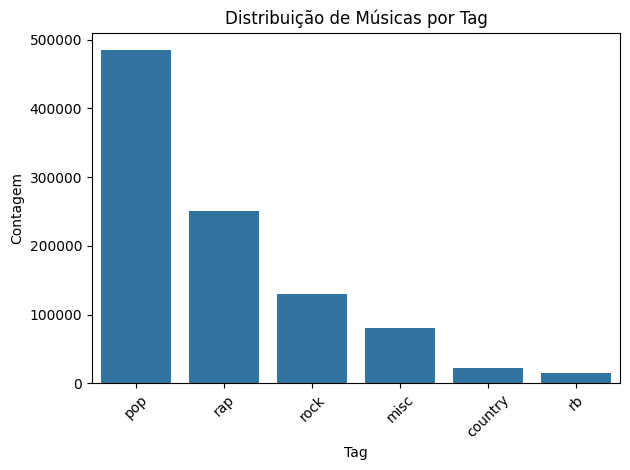

In [ ]:
plt.figure()
ax = sns.countplot(data=df, x='tag', order=df['tag'].value_counts().index)
ax.set_title("Distribuição de Músicas por Tag")
ax.set_xlabel("Tag")
ax.set_ylabel("Contagem")
ax.tick_params(axis='x', rotation=45)
plt.tight_layout()
plt.show()

Percebe-se que a distribuição de tags não é balanceada.

E depende da maneira que é feita a amostragem.

Vamos agora ver os artistas com mais views em cada gênero.

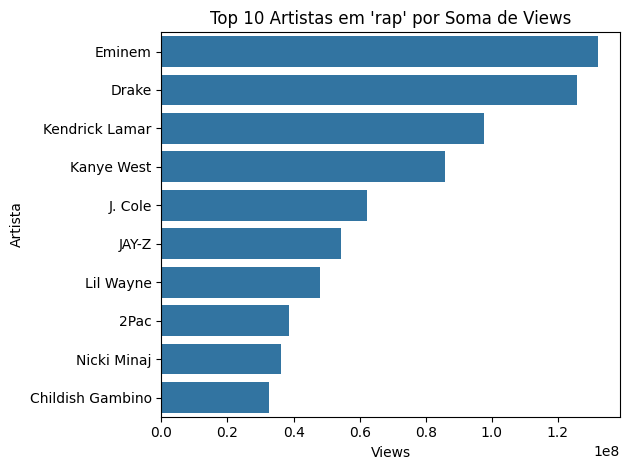

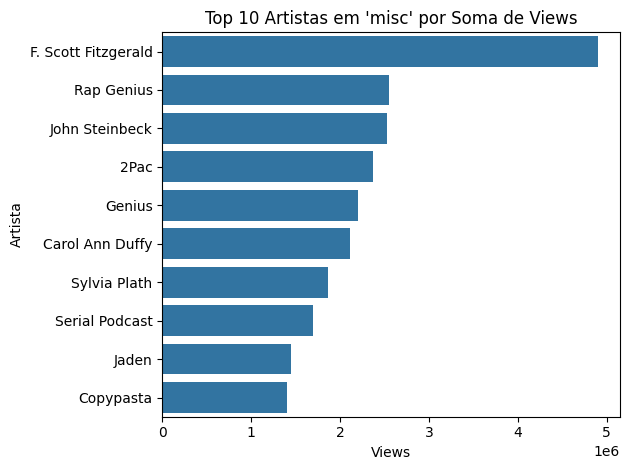

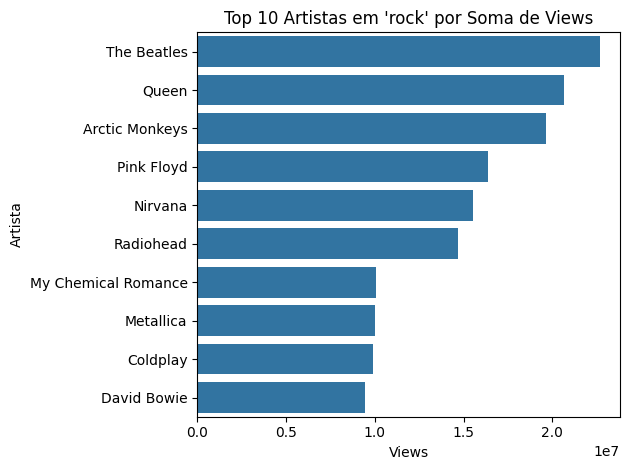

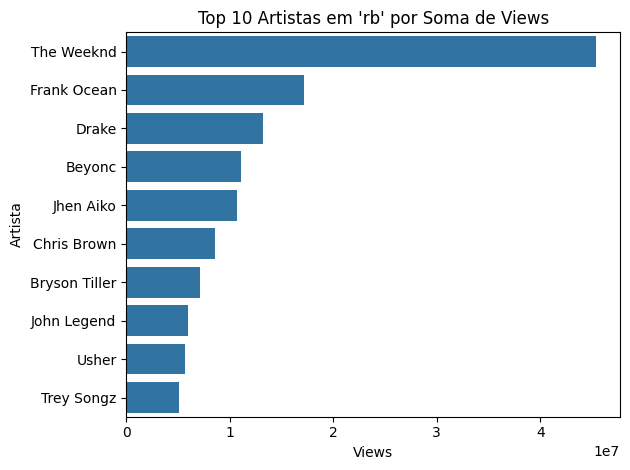

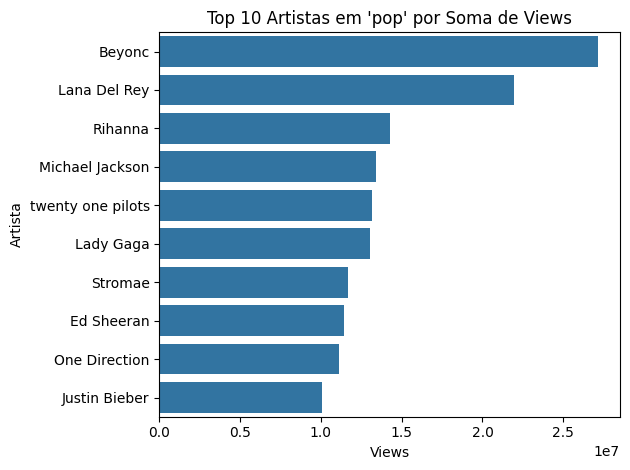

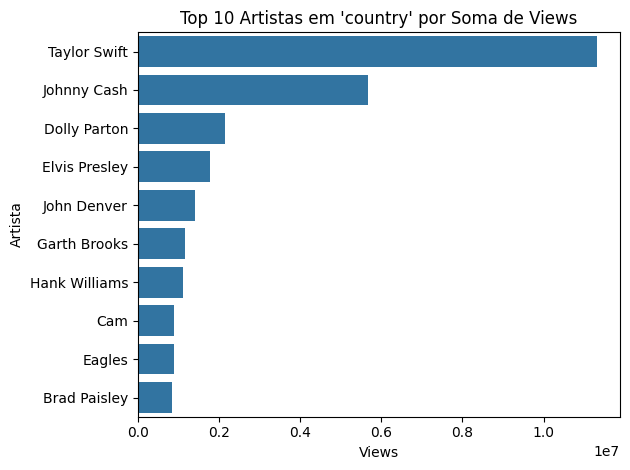

In [ ]:
tags = df['tag'].unique()
for tag in tags:
    sub = df[df['tag'] == tag]
    top10 = (
        sub.groupby('artist')['views']
           .sum()
           .sort_values(ascending=False)
           .head(10)
           .reset_index()
    )
    plt.figure()
    sns.barplot(data=top10, x='views', y='artist', orient='h')
    plt.title(f"Top 10 Artistas em '{tag}' por Soma de Views")
    plt.xlabel("Views")
    plt.ylabel("Artista")
    plt.tight_layout()
    plt.show()

Vamos ver a distribuição dos idiomas (aqueles com pelo menos 1000 instâncias associadas):

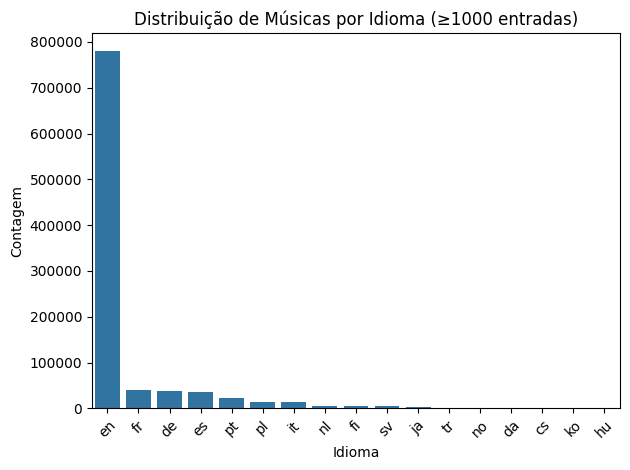

In [ ]:
# Contagem de cada idioma
lang_counts = df['language'].value_counts()

# Filtrar
langs_validos = lang_counts[lang_counts >= 1000].index
df_lang = df[df['language'].isin(langs_validos)]

plt.figure()
ax = sns.countplot(data=df_lang, x='language', order=langs_validos)
ax.set_title("Distribuição de Músicas por Idioma (≥1000 entradas)")
ax.set_xlabel("Idioma")
ax.set_ylabel("Contagem")
ax.tick_params(axis='x', rotation=45)
plt.tight_layout()
plt.show()

Inglês é o idioma disparado mais comum.

Vamos visualizar como os views estão distribuídos em uma escala log, para facilitar visualização.

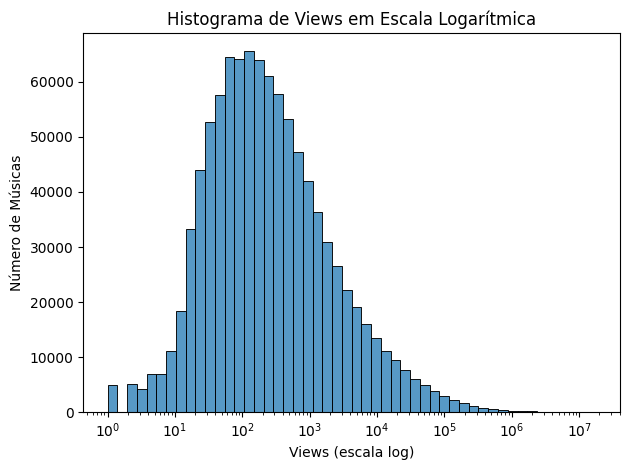

In [ ]:
plt.figure()
sns.histplot(data=df, x='views', bins=50, log_scale=(True, False))
plt.title("Histograma de Views em Escala Logarítmica")
plt.xlabel("Views (escala log)")
plt.ylabel("Número de Músicas")
plt.tight_layout()
plt.show()

Agora, podemos perceber que nosso gráfico (com views em escala log) se assemelha, de certa maneira, a uma distribuição normal, um pouco deslocada para a esquerda, ou seja, com a cauda longa na direita, então a maior parte dos nossos dados está presente por volta de 10² a 10³ views. Com pouquíssimos representantes acima dos 10⁶ views.

Text(0.5, 0, 'Views (escala log)')

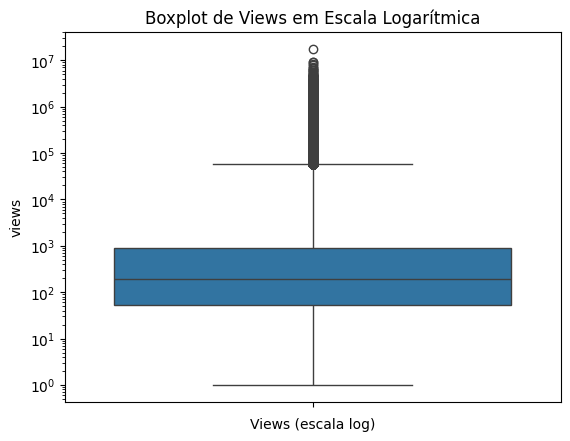

In [ ]:
plt.figure()
sns.boxplot(data=df, y='views', log_scale=True)
plt.title("Boxplot de Views em Escala Logarítmica")
plt.xlabel("Views (escala log)")

Aqui vemos as views em um boxplot evidenciando o que foi comentado anteriormente.

Desse modo, deve ser elaborada alguma estratégia para tratar os outliers, para que eles ainda sejam representados, mas dentro de um intervalo aceitável.

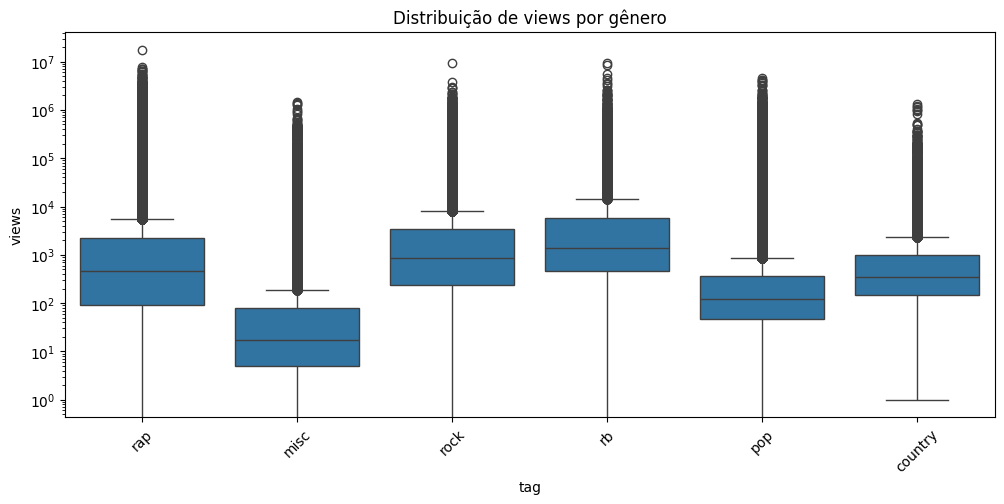

In [ ]:
plt.figure(figsize=(12,5))
sns.boxplot(x='tag', y='views', data=df)
plt.title('Distribuição de views por gênero')
plt.xticks(rotation=45)
plt.yscale('log')
plt.show()


Podemos perceber os outliers e as médias de views de acordo com cada gênero.

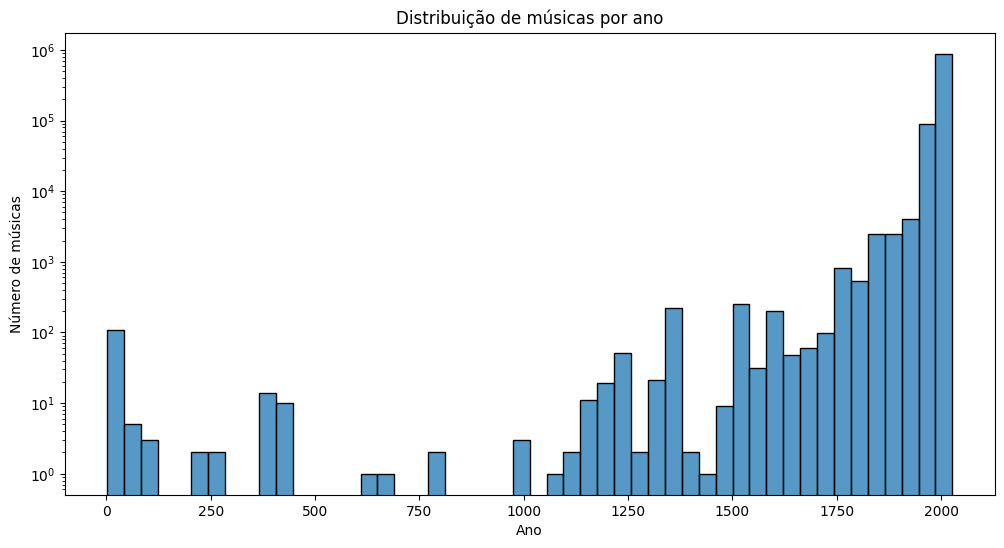

In [ ]:
plt.figure(figsize=(12,6))
sns.histplot(df['year'], bins=50, kde=False)
plt.title('Distribuição de músicas por ano')
plt.xlabel('Ano')
plt.ylabel('Número de músicas')
# escala log
plt.yscale('log')
plt.show()


Aqui vemos a distribuição do ano de produção e o número de amostras relacionados.

E percebemos que estão concentradas mais próximas dos anos 2000.

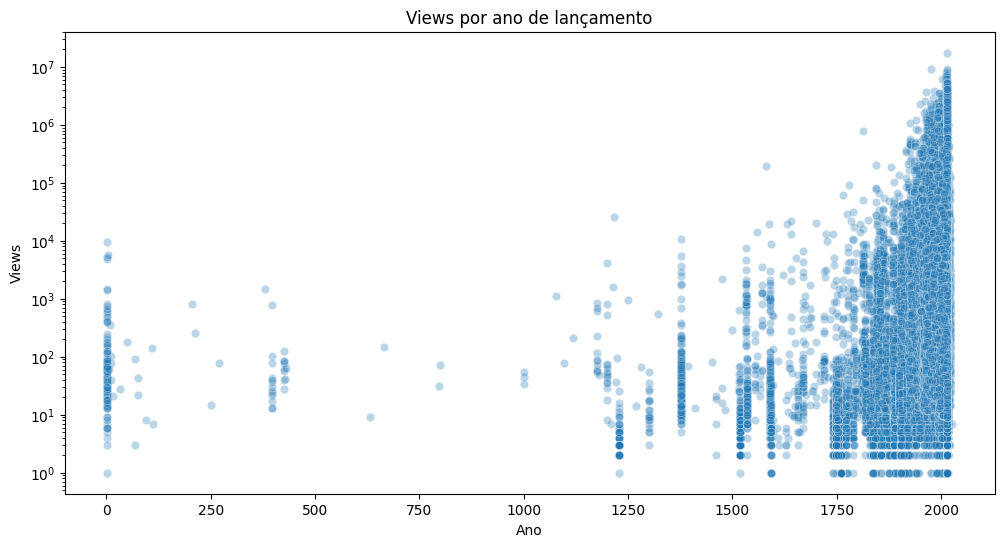

In [ ]:
plt.figure(figsize=(12,6))
sns.scatterplot(x='year', y='views', data=df, alpha=0.3)
plt.title('Views por ano de lançamento')
plt.xlabel('Ano')
plt.ylabel('Views')
plt.yscale('log')
plt.show()


Aqui vemos que, além de amostras, as views também estão concentradas nos anos 2000.

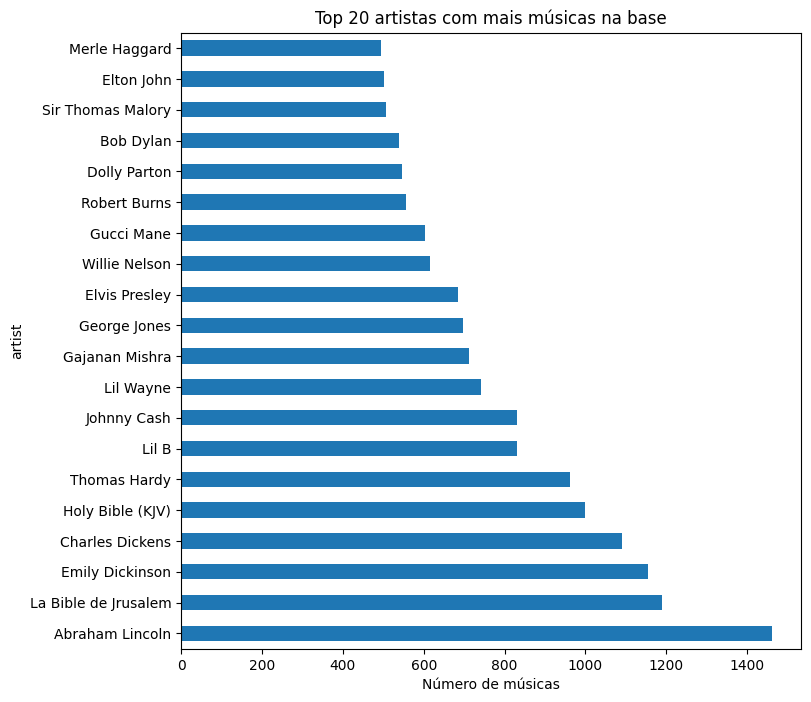

In [ ]:
df['artist'].value_counts().head(20).plot(kind='barh', figsize=(8,8))
plt.title('Top 20 artistas com mais músicas na base')
plt.xlabel('Número de músicas')
plt.show()


Aqui percebemos os artistas com mais amostras na base.

# 2) Tratar a base: normalizar os dados, eliminar atributos que julguem irrelevantes e realizar outros ajuste que julgar importantes.

Vamos normalizar os dados numéricos (views e year).

Com views, vamos primeiramente realizar uma transformação logarítmica de modo a lidar com os outliers, que estão muito distantes, e após isso normalizar.

In [12]:
from sklearn.preprocessing import MinMaxScaler

def normaliza_views(df):
  # reduzindo escala dos outliers com log 1 + x
  log_views = np.log1p(df['views'])

  # normaliza entre 0 e 1
  scaler = MinMaxScaler()
  views_scaled = scaler.fit_transform(log_views.values.reshape(-1, 1))
  year_scaled = scaler.fit_transform(df['year'].values.reshape(-1, 1))

  df['views'] = views_scaled.flatten()
  df['year'] = year_scaled.flatten()

  return df

In [ ]:
df = normaliza_views(df)
display(df[['views', 'year']].describe())

,views,year
count,904817.000000,904817.000000
mean,0.313973,0.988402
std,0.125396,0.010104
min,0.000000,0.000000
25%,0.220551,0.986180
50%,0.295390,0.990128
75%,0.386520,0.993090
max,1.000000,1.000000


([0, 1, 2, 3, 4],
 [Text(0, 0, 'rap'),
  Text(1, 0, 'rock'),
  Text(2, 0, 'rb'),
  Text(3, 0, 'pop'),
  Text(4, 0, 'country')])

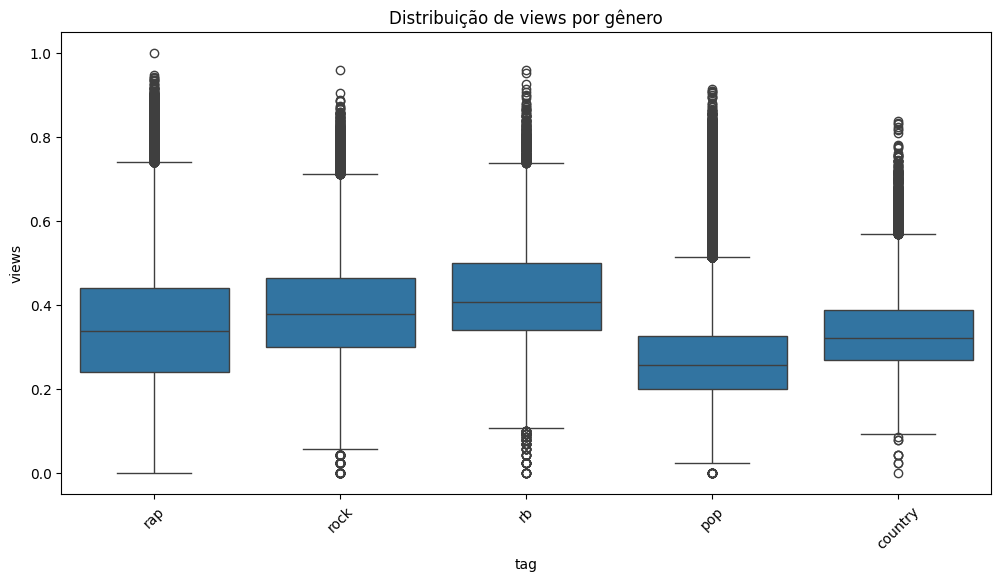

In [ ]:
# plot box plot de views e year:
plt.figure(figsize=(12,6))
sns.boxplot(x='tag', y='views', data=df)
plt.title('Distribuição de views por gênero')
plt.xticks(rotation=45)

Agora os dados numéricos foram normalizados corretamente.

Agora vamos tratar problemas em ```lyrics```:

- removendo lyrics vazios, definindo um número mínimo e máximo de palavras, removendo lyrics iguais e removendo expressões regulares estranhas (como timestamps, colchetes, simbolos, etc)

In [13]:
import re
# Compilar padrões fora da função
re_timestamp = re.compile(r'\[\s*[\d:\.]+\s*\]')
re_tag_brackets = re.compile(r'\[\s*[^\]]*\s*\]')
re_verse = re.compile(r'\(.*?verse.*?\)', flags=re.I)
re_repeticao = re.compile(r'\b(\w+)( \1\b){3,}')
re_non_ascii = re.compile(r'[^\x00-\x7F]+')
re_symbols = re.compile(r'[^a-zA-Z0-9\s\.,!?\'\"-]')
re_mult_space = re.compile(r'\s+')

def ajustar_lyrics(text):
    text = re_timestamp.sub('', text)
    text = re_tag_brackets.sub('', text)
    text = re_verse.sub('', text)
    text = re_repeticao.sub(r'\1 \1', text)
    text = re_non_ascii.sub(' ', text)
    text = re_symbols.sub('', text)
    text = re_mult_space.sub(' ', text).strip()
    text = re.sub(r'<.*?>', '', text)
    return text


In [ ]:
df['lyrics'] = df['lyrics'].apply(ajustar_lyrics)

In [ ]:
# verificar lyrics vazia:
print_cor("lyrics vazia:")
print(df[df['lyrics'].isnull()])

import re
# Remover nulos e vazios
df = df[df['lyrics'].notnull()]
df = df[df['lyrics'].str.strip() != '']

lyrics vazia:
Empty DataFrame
Columns: [title, tag, artist, year, views, features, lyrics, language]
Index: []


In [ ]:
# Tamanho mínimo (>= 10 palavras)
# df = df[df['lyrics'].str.split().str.len() >= 10]
# Aproximação: número de palavras = número de espaços + 1
df = df[df['lyrics'].str.count(' ') >= 9]

# Tamanho máximo opcional (ex: <= 10.000 caracteres)
df = df[df['lyrics'].str.len() <= 10000]

In [ ]:
# remover lyrics iguais:
df = df.drop_duplicates(subset='lyrics')

In [14]:
def limpar_lyrics(df):
    df = df.copy()  # garante que é uma cópia independente
    df['lyrics'] = df['lyrics'].apply(ajustar_lyrics)
    # verificar lyrics vazia:
    print_cor("lyrics vazia:")
    print(df[df['lyrics'].isnull()])
    # Remover nulos e vazios
    df = df[df['lyrics'].notnull()]
    df = df[df['lyrics'].str.strip() != '']
    df = df[df['lyrics'].str.count(' ') >= 9]
    df = df[df['lyrics'].str.len() <= 10000]
    df = df.drop_duplicates(subset='lyrics')
    return df

In [ ]:
df.describe(include='all')

,title,tag,artist,year,views,features,lyrics,language
count,889650,889650,889650,889650.000000,889650.000000,889650,889650,889650
unique,613936,5,92968,NaN,NaN,59310,889650,99
top,Intro,pop,Johnny Cash,NaN,NaN,{},"On a windy day, let's go on flying There may b...",en
freq,903,473516,826,NaN,NaN,748950,1,695714
mean,NaN,NaN,NaN,0.988388,0.314988,NaN,NaN,NaN
std,NaN,NaN,NaN,0.010130,0.125402,NaN,NaN,NaN
min,NaN,NaN,NaN,0.000000,0.000000,NaN,NaN,NaN
25%,NaN,NaN,NaN,0.986180,0.221464,NaN,NaN,NaN
50%,NaN,NaN,NaN,0.990128,0.296218,NaN,NaN,NaN
75%,NaN,NaN,NaN,0.993090,0.387547,NaN,NaN,NaN


Agora percebe-se que todas lyrics são únicas e o tratamento foi feito de maneira correta.

Vamos ajustar ```artist``` para letras minúsculas e sem símbolos especiais:

In [15]:
def limpar_artist(name: str) -> str:
    # Remove espaços e normaliza maiúsculas/minúsculas
    name = name.strip()
    name = ' '.join(name.split())  # remove múltiplos espaços
    name = name.title()  # coloca em Title Case

    # Remove barras invertidas escapadas
    name = re.sub(r'\\(.)', r'\1', name)

    # Remove caracteres especiais (deixa letras, números, espaços, & e -)
    name = re.sub(r"[^a-zA-Z0-9 $&\-']", '', name)

    return name


In [ ]:
df['artist'] = df['artist'].apply(limpar_artist)

Por fim, vamos fazer uma limpeza em ```features```:

In [ ]:
display(df[['artist', 'features']].head(20))

,artist,features
0,Cam'ron,"{""Cam\\'ron"",""Opera Steve""}"
1,JAY-Z,{}
2,Fabolous,{}
3,Cam'ron,"{""Cam\\'ron"",""Kanye West"",""Syleena Johnson""}"
4,Lil Wayne,{}
5,Lil Wayne,"{""Kanye West"",""Static Major""}"
6,Clipse,"{Jadakiss,""Styles P"",""Roscoe P. Coldchain""}"
7,Cam'ron,"{""Cam\\'ron"",""Lady Wray""}"
8,Cam'ron,"{""Cam\\'ron""}"
9,Cam'ron,"{""Cam\\'ron"",""Juelz Santana"",Jaheim}"


In [16]:
import re

def limpar_features(df):
    df = df.copy()  # garante que é uma cópia independente

    def parse_features(features_str):
      if not isinstance(features_str, str) or features_str.strip() == '{}':
          return []

      # Remove chaves externas
      inner = features_str.strip()
      if inner.startswith('{') and inner.endswith('}'):
          inner = inner[1:-1]

      # Expressão regular para separar por vírgulas, respeitando nomes entre aspas
      raw = re.split(r',\s*(?=(?:[^"]*"[^"]*")*[^"]*$)', inner)

      # Limpa aspas e espaços de cada nome
      clean = [re.sub(r'^["\']|["\']$', '', f.strip()) for f in raw]

      # Filtra vazios
      return [f for f in clean if f]

    # limpa as features antes:
    df['features'] = df['features'].apply(parse_features)

    def normalize_whitespace(s: str) -> str:
        return re.sub(r'\s+', ' ', s).strip()

    def strip_parentheses(name: str) -> str:
        return normalize_whitespace(re.sub(r'\s*\(.*?\)', '', name))

    def remove_all_escaped_backslashes(s: str) -> str:
        # Retorna a string sem barras invertidas '\'
        return re.sub(r'\\', '', s)

    def normalize_feature_name(name: str) -> str:
        if not isinstance(name, str):
            return ''
        name = remove_all_escaped_backslashes(name)
        name = re.sub(r"[^\w\s&$\-\']", '', name, flags=re.UNICODE)
        name = strip_parentheses(name.lower().strip())
        return name

    def clean_features_list(row):
        artist = row['artist'].lower().strip()
        features = row['features']

        clean_feats = [normalize_feature_name(f) for f in features if isinstance(f, str)]

        clean_feats = [f for f in clean_feats if f != artist and f != '']

        # Remove duplicatas preservando ordem
        clean_feats = list(dict.fromkeys(clean_feats))

        return clean_feats

    def is_self_collab(row) -> bool:
        artist = normalize_feature_name(row['artist'])
        feats = clean_features_list(row)
        return len(feats) > 0 and all(f == artist for f in feats)

    # Aplica limpeza na coluna features
    df['features'] = df.apply(clean_features_list, axis=1)

    # Remove colabs que só têm o próprio artista
    df = df[~df.apply(is_self_collab, axis=1)].copy()

    stopwords_colab = {'chorus', 'verse', 'featuring', 'intro', 'outro', 'bridge', 'interlude'}
    df.loc[:, 'features'] = df['features'].apply(
        lambda lst: [name for name in lst if name not in stopwords_colab]
    )

    return df


In [ ]:
df = limpar_features(df)

Agora vamos deixar essas últimas mudanças todas em uma função para facilitar futuramente:

In [17]:
def limpeza_dados_completa(df):
  df = limpeza_dados(df)
  df = remove_anos_anormais(df)
  df = limpar_lyrics(df)
  df['artist'] = df['artist'].apply(limpar_artist)
  df = limpar_features(df)
  df = normaliza_views(df)
  return df

Vamos tentar uma maneira de ler os dados de modo que as tags estejam balanceadas em quantidade de amostras:

In [18]:
import pandas as pd
import os

# Configurações
chunk_size = 10000
total_por_tag = 1000  # por exemplo
tags_desejadas = ['pop', 'rap', 'rock', 'country', 'rb']
coletados_por_tag = {tag: 0 for tag in tags_desejadas}
dfs_por_tag = {tag: [] for tag in tags_desejadas}

limite_total = total_por_tag * len(tags_desejadas)

# Leitura chunked
for chunk in pd.read_csv(caminho_dados, chunksize=chunk_size):
    for tag in tags_desejadas:
        if coletados_por_tag[tag] < total_por_tag:
            chunk_tag = chunk[chunk['tag'] == tag]
            restante = total_por_tag - coletados_por_tag[tag]
            if len(chunk_tag) > 0:
                amostra = chunk_tag.sample(min(len(chunk_tag), restante), random_state=42)
                dfs_por_tag[tag].append(amostra)
                coletados_por_tag[tag] += len(amostra)

    # Para se quiser encerrar antes por segurança
    if sum(coletados_por_tag.values()) >= limite_total:
        break

# Junta tudo
amostras_balanceadas = pd.concat(
    [pd.concat(dfs_por_tag[tag], ignore_index=True) for tag in tags_desejadas],
    ignore_index=True
)

# Salva se quiser reutilizar depois
amostras_balanceadas.to_csv("amostra_balanceada.csv", index=False)


In [ ]:
print(f'Total de amostras coletadas: {len(amostras_balanceadas)}')

Total de amostras coletadas: 2500


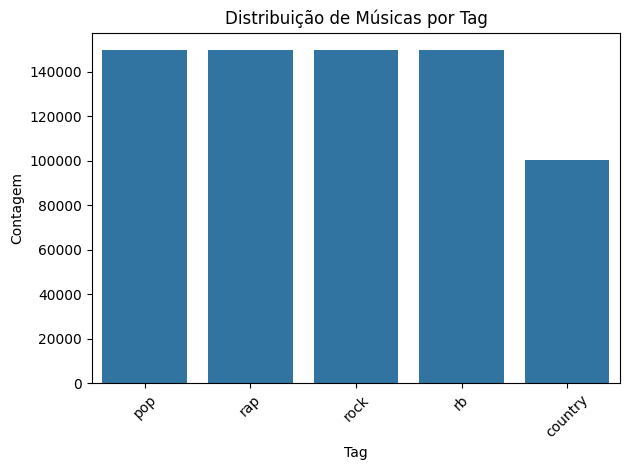

In [ ]:
plt.figure()
ax = sns.countplot(data=amostras_balanceadas, x='tag', order=amostras_balanceadas['tag'].value_counts().index)
ax.set_title("Distribuição de Músicas por Tag")
ax.set_xlabel("Tag")
ax.set_ylabel("Contagem")
ax.tick_params(axis='x', rotation=45)
plt.tight_layout()
plt.show()

In [19]:
amostras_balanceadas = limpeza_dados_completa(amostras_balanceadas)

<class 'pandas.core.frame.DataFrame'>
Index: 4988 entries, 0 to 4999
Data columns (total 9 columns):
 #   Column    Non-Null Count  Dtype 
---  ------    --------------  ----- 
 0   title     4988 non-null   object
 1   tag       4988 non-null   object
 2   artist    4988 non-null   object
 3   year      4988 non-null   int64 
 4   views     4988 non-null   int64 
 5   features  4988 non-null   object
 6   lyrics    4988 non-null   object
 7   id        4988 non-null   int64 
 8   language  4988 non-null   object
dtypes: int64(3), object(6)
memory usage: 389.7+ KB
copias reais (titulo, artista, ano): 0
Empty DataFrame
Columns: [title, tag, artist, year, views, features, lyrics, language]
Index: []
      artist         mean      std
0  The Doors  1967.727273  1.61808
lyrics vazia:
Empty DataFrame
Columns: [title, tag, artist, year, views, features, lyrics, language]
Index: []


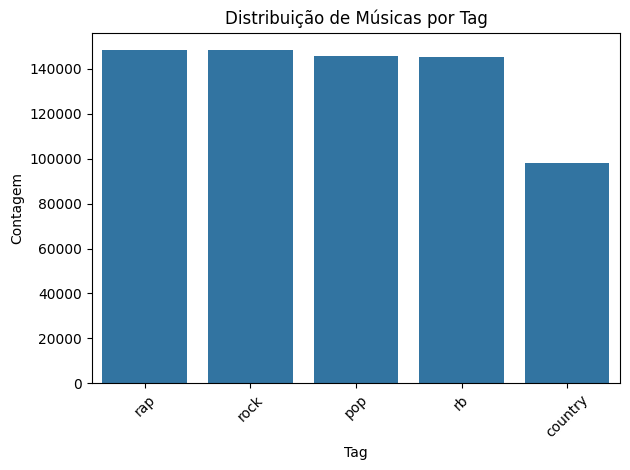

In [ ]:
plt.figure()
ax = sns.countplot(data=amostras_balanceadas, x='tag', order=amostras_balanceadas['tag'].value_counts().index)
ax.set_title("Distribuição de Músicas por Tag")
ax.set_xlabel("Tag")
ax.set_ylabel("Contagem")
ax.tick_params(axis='x', rotation=45)
plt.tight_layout()
plt.show()

In [ ]:
amostras_balanceadas.describe(include='all')

,title,tag,artist,year,views,features,lyrics,language
count,246959,246959,246959,246959.000000,246959.000000,246959,246959,246959
unique,181556,5,30500,NaN,NaN,23101,246959,81
top,Intro,rap,Johnny Cash,NaN,NaN,[],Breana Marin How can you tell What s wrong fro...,en
freq,195,49914,801,NaN,NaN,199035,1,226120
mean,NaN,NaN,NaN,0.989881,0.397902,NaN,NaN,NaN
std,NaN,NaN,NaN,0.011436,0.141894,NaN,NaN,NaN
min,NaN,NaN,NaN,0.000000,0.000000,NaN,NaN,NaN
25%,NaN,NaN,NaN,0.987135,0.295604,NaN,NaN,NaN
50%,NaN,NaN,NaN,0.992083,0.385558,NaN,NaN,NaN
75%,NaN,NaN,NaN,0.995547,0.488820,NaN,NaN,NaN


In [ ]:
display(amostras_balanceadas[['artist', 'features']].head(30))

,artist,features
0,Travie Mccoy,[bruno mars]
1,Beyonc,"[kanye west, beyoncé]"
2,Tom Tom Club,[]
3,Kid Cudi,[]
4,Drake,[]
5,Kanye West,[]
6,Vampire Weekend,[]
7,Lady Gaga,[]
8,Justin Bieber,[ludacris]
9,Ceelo Green,[]


# 3) Realizar uma das tarefas abaixo:

## d) Verifique a rede de colaboração de artistas através de um grafo. Encontre comunidades de colaboração neste grafo.

In [ ]:
df_grafo = amostras_balanceadas.copy()

In [ ]:
# Apenas músicas com views acima do percentil inferior
porc = 0.1
lim_inf_views = df_grafo['views'].quantile(porc)
outliers_views = df_grafo[df_grafo['views'] < lim_inf_views]
print_cor(f"Views limite inferior (percentil {porc*100}%): {int(lim_inf_views)}")
print_cor(f"Num amostras removidas por views abaixo do limite: {len(outliers_views)}")
df_grafo = df_grafo[df_grafo['views'] >= lim_inf_views]

# Manter apenas músicas com colaboração explícita (baseado na coluna 'features' não nula e não vazia)
num_antes_features = len(df_grafo)
df_grafo = df_grafo[
    df_grafo['features'].notnull() &
    (df_grafo['features'].str.strip() != '') &
    (df_grafo['features'].str.strip() != '{}')
]
num_depois_features = len(df_grafo)
print_cor(f"Num amostras removidas por não ter colaboração (features vazia ou chaves): {num_antes_features - num_depois_features}")

# Apenas artistas com pelo menos 10 músicas colaborativas
num_min_colabs = 10
artistas_colabs = df_grafo['artist'].value_counts()
artistas_validos = artistas_colabs[artistas_colabs >= num_min_colabs].index
num_antes_artistas = len(df_grafo)
df_grafo = df_grafo[df_grafo['artist'].isin(artistas_validos)]
num_depois_artistas = len(df_grafo)
print_cor(f"Num amostras removidas por artistas com menos de {num_min_colabs} colaborações: {num_antes_artistas - num_depois_artistas}")

print_cor(f"Total final de instâncias para grafo: {len(df_grafo)}")

display(df_grafo.head())
print('\n')
display(df_grafo.describe(include='all'))

In [ ]:
df_grafo_pop = df_grafo[df_grafo['tag'] == 'pop'].copy()
print(f"Número de amostras com genero pop: {len(df_grafo_pop)}")

df_grafo_country = df_grafo[df_grafo['tag'] == 'country'].copy()
print(f"Número de amostras com genero country: {len(df_grafo_country)}")

df_grafo_rb = df_grafo[df_grafo['tag'] == 'rb'].copy()
print(f"Número de amostras com genero rb: {len(df_grafo_rb)}")

df_grafo_rap = df_grafo[df_grafo['tag'] == 'rap'].copy()
print(f"Número de amostras com genero rap: {len(df_grafo_rap)}")

df_grafo_rock = df_grafo[df_grafo['tag'] == 'rock'].copy()
print(f"Número de amostras com genero rock: {len(df_grafo_rock)}")


Número de amostras com genero pop: 928
Número de amostras com genero country: 127
Número de amostras com genero rb: 650
Número de amostras com genero rap: 335
Número de amostras com genero rock: 1095


In [ ]:
# Manter apenas os X% de amostras com mais views
porc_top_views = 0.2
lim_sup_views = df_grafo['views'].quantile(1 - porc_top_views)
# print_cor(f"Views limite superior (percentil {(1-porc_top_views)*100}%): {int(lim_sup_views)}")

num_antes_top_views = len(df_grafo)
df_grafo = df_grafo[df_grafo['views'] >= lim_sup_views]
num_depois_top_views = len(df_grafo)

print_cor(f"Num amostras removidas para manter apenas o top {porc_top_views*100}% de views: {num_antes_top_views - num_depois_top_views}")
print_cor(f"Total final de instâncias para grafo após filtro de top views: {len(df_grafo)}")

display(df_grafo.head())
print('\n')
display(df_grafo.describe(include='all'))


Num amostras removidas para manter apenas o top 20.0% de views: 12538
Total final de instâncias para grafo após filtro de top views: 3135


,title,tag,artist,year,views,features,lyrics,language
1,Whats My Name?,pop,Rihanna,0.994062,0.828112,[drake],"Oh na-na, what's my name? Oh na-na, what's my ...",en
3,Eleanor Rigby,pop,The Beatles,0.972291,0.821571,[],"Ah, look at all the lonely people! Ah, look at...",en
4,The Other Side,pop,Bruno Mars,0.994062,0.650328,"[bob, ceelo green]",Truth of the matter is I'm complicated You're ...,en
5,LoveGame,pop,Lady Gaga,0.993568,0.739440,[],"Let's have some fun, this beat is sick I wanna...",en
7,Skin,pop,Rihanna,0.994062,0.720851,[],"The mood is set Huh, huh So you already know w...",en


,title,tag,artist,year,views,features,lyrics,language
count,3135,3135,3135,3135.000000,3135.000000,3135,3135,3135
unique,3045,5,367,NaN,NaN,360,3135,5
top,Without You,rock,The Beatles,NaN,NaN,[],"Now that we have found this love, baby I can't...",en
freq,3,1095,83,NaN,NaN,2593,1,3087
mean,NaN,NaN,NaN,0.989425,0.713590,NaN,NaN,NaN
std,NaN,NaN,NaN,0.006868,0.063055,NaN,NaN,NaN
min,NaN,NaN,NaN,0.952994,0.631329,NaN,NaN,NaN
25%,NaN,NaN,NaN,0.986640,0.662850,NaN,NaN,NaN
50%,NaN,NaN,NaN,0.992083,0.699727,NaN,NaN,NaN
75%,NaN,NaN,NaN,0.994557,0.751521,NaN,NaN,NaN



Total de comunidades (Louvain) detectadas: 8

Comunidade 0 (tamanho 12): ['busta rhymes', 'christina aguilera', 'ciara', 'j cole', 'keyshia cole', 'kid cudi', 'lauryn hill', "lil' kim", 'ludacris', 'mary j blige', 'missy elliott', 'wale']
Comunidade 1 (tamanho 19): ['ariana grande', 'big sean', 'bob', 'bruno mars', 'ceelo green', 'childish gambino', 'erykah badu', 'gorillaz', 'janelle mone', 'jessie j', 'jhen aiko', 'kanye west', 'katy perry', 'keri hilson', 'lupe fiasco', 'miguel', 'outkast', 'stromae', 'yasiin bey']
Comunidade 2 (tamanho 2): ['ed sheeran', 'taylor swift']
Comunidade 3 (tamanho 6): ['enrique iglesias', 'ja rule', 'jennifer lopez', 'ne-yo', 'pitbull', 'shakira']
Comunidade 4 (tamanho 30): ['aaliyah', 'alicia keys', 'august alsina', 'britney spears', 'calvin harris', 'chance the rapper', 'chris brown', 'david guetta', 'drake', 'fabolous', 'jay-z', 'jeezy', 'john legend', 'juicy j', 'justin bieber', 'justin timberlake', 'lil wayne', 'madonna', 'mariah carey', 'nicki min

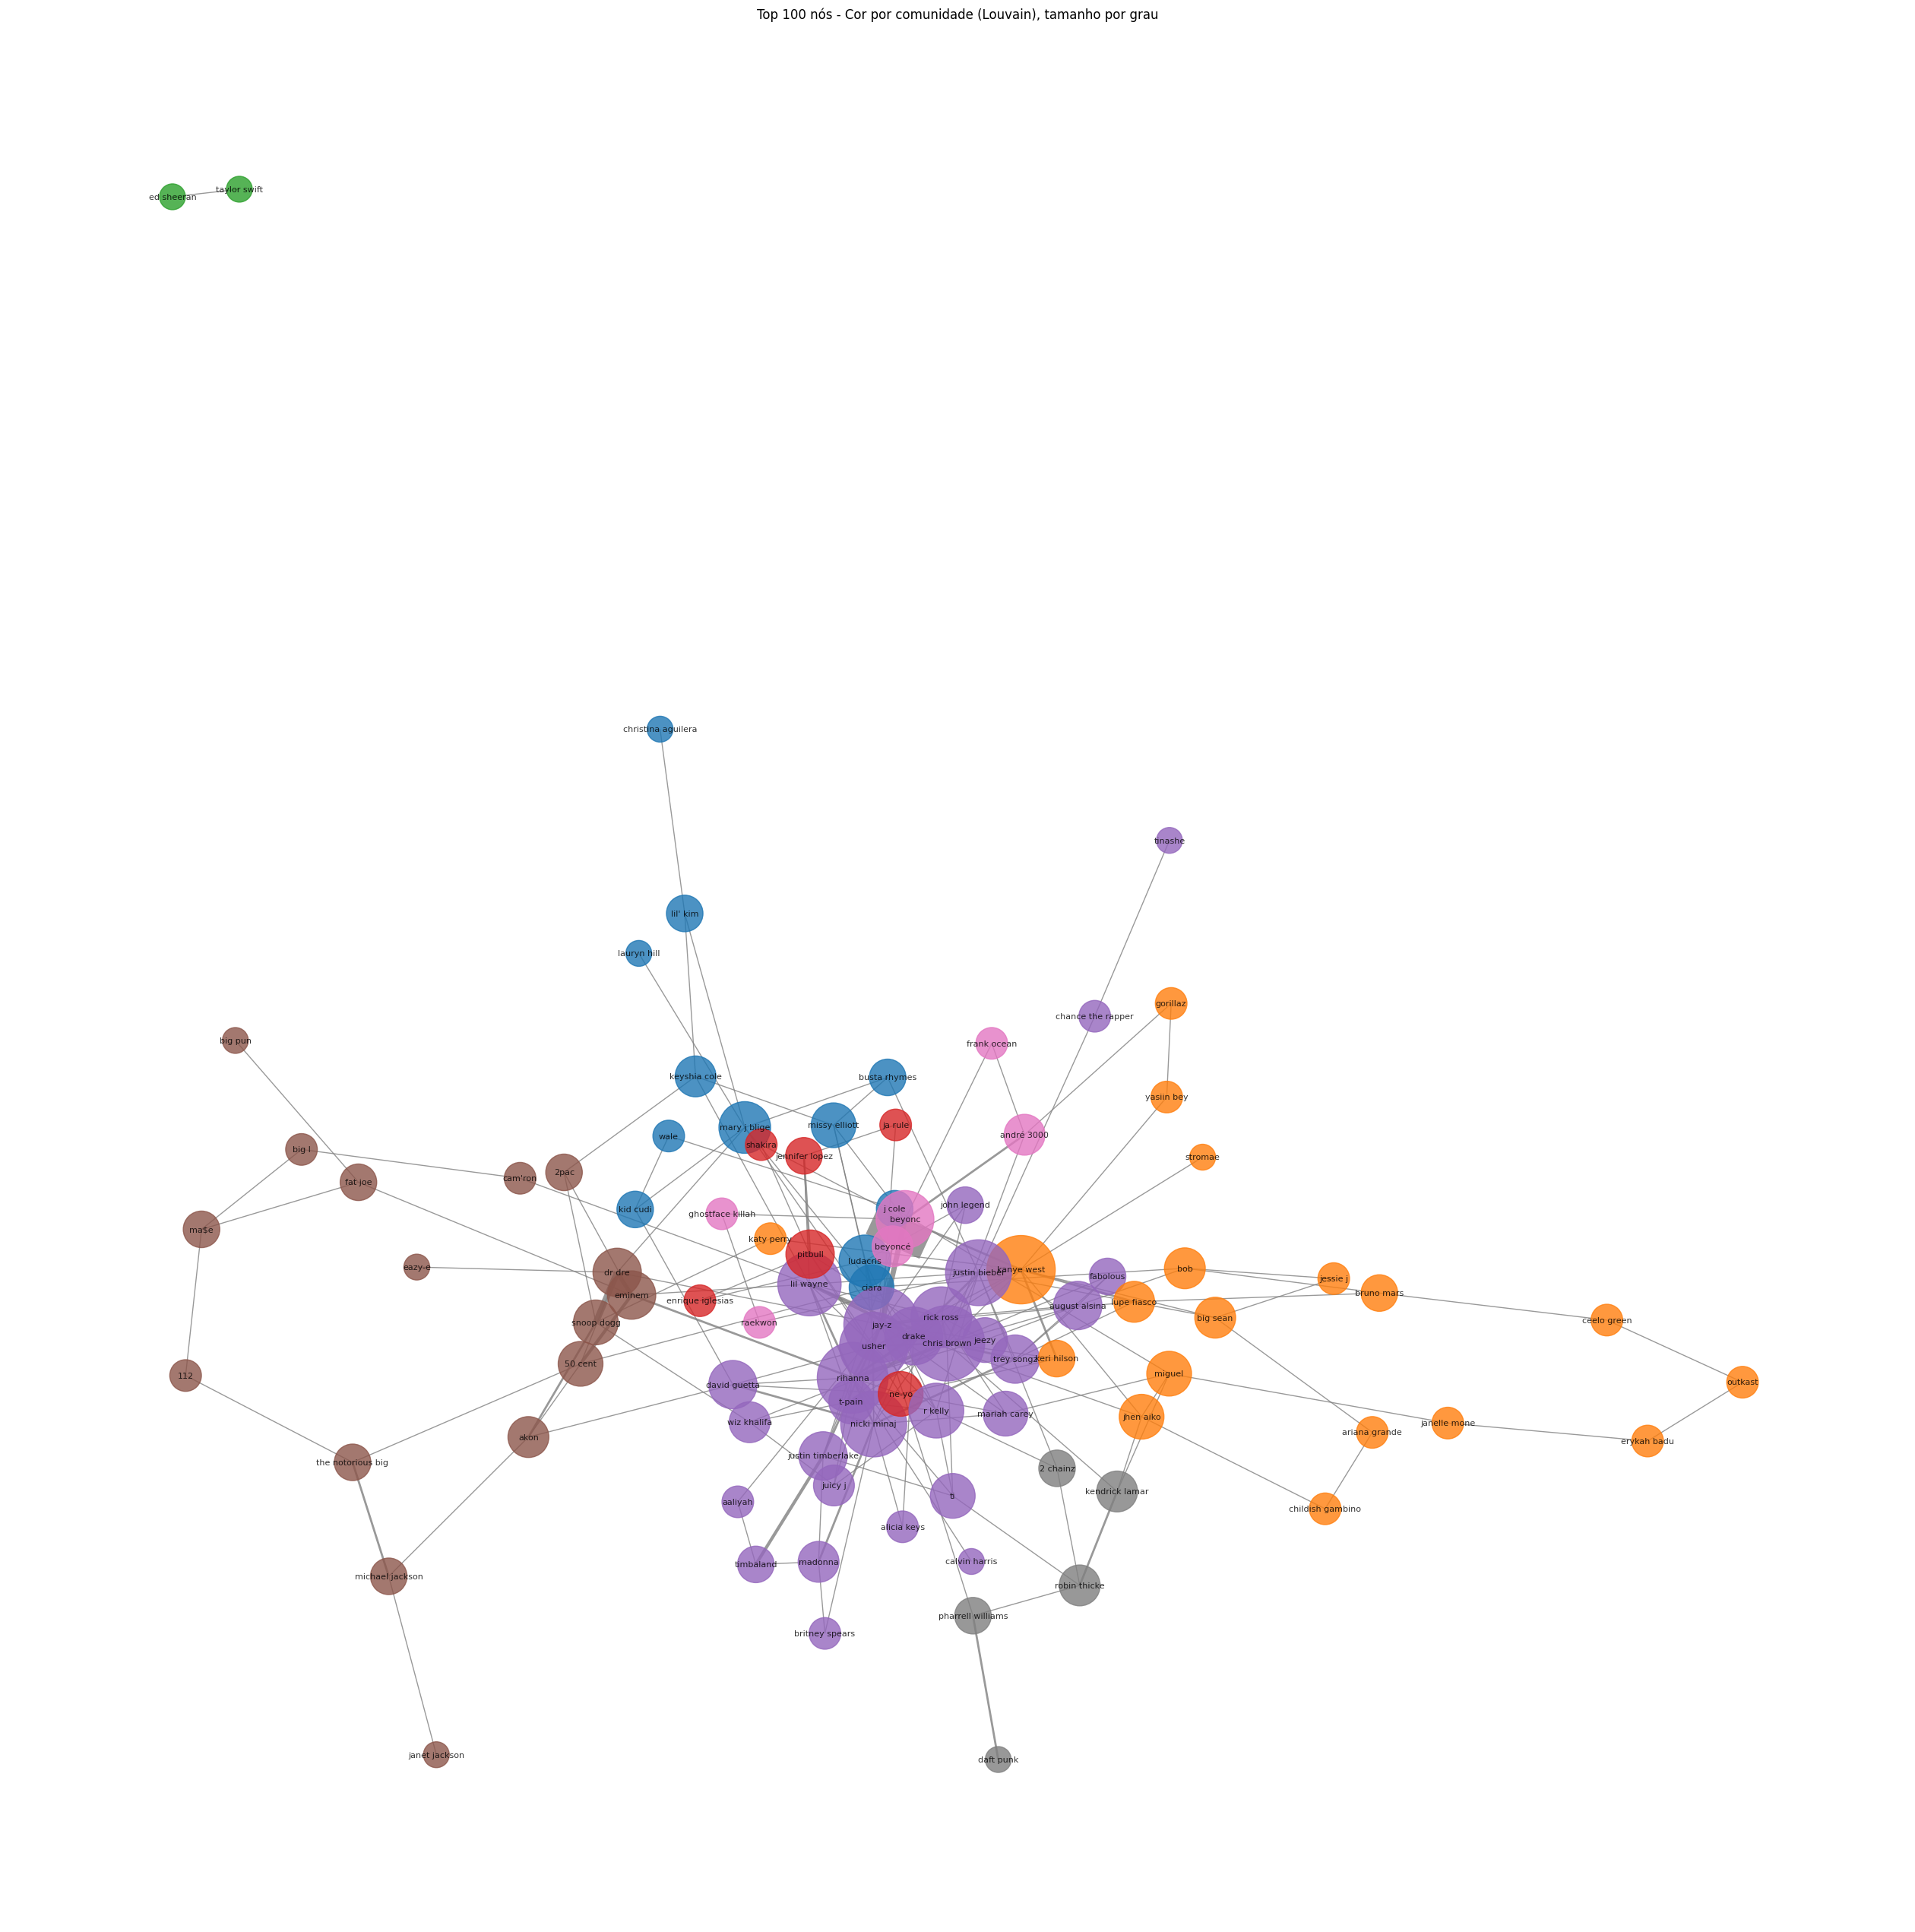

In [ ]:
import re
import networkx as nx
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
from networkx.algorithms.community import greedy_modularity_communities
import community as community_louvain  # <- Pacote python-louvain
from networkx.algorithms.community import modularity
import community.community_louvain as community_louvain


# ======== Funções de limpeza de nomes ========
def normalize_whitespace(s: str) -> str:
    return re.sub(r'\s+', ' ', s).strip()

def strip_parentheses(name: str) -> str:
    return normalize_whitespace(re.sub(r'\s*\(.*?\)', '', name))

def normalize_artist_name(name: str) -> str:
    return strip_parentheses(name).lower()

def parse_features(features_str: str) -> list[str]:
    inner = features_str.strip()[1:-1]
    pattern = re.compile(r'"(.*?)"|\'(.*?)\'|([^,]+)')
    names = []
    for m in pattern.finditer(inner):
        raw = m.group(1) or m.group(2) or m.group(3)
        raw = raw.replace('\\$', '$').replace('\\', '')
        clean = normalize_whitespace(raw)
        if clean:
            names.append(clean)
    return names

def extract_collaborators(artist: str, features: list) -> list[str]:
    artist_base = normalize_artist_name(artist)
    if not isinstance(features, list):
        return []
    return [name for name in features if normalize_artist_name(name) != artist_base]

# ======== Construção do grafo ========
G = nx.Graph()

for row in df_grafo.itertuples(index=False):
    artista_raw = row.artist
    collabs_raw = extract_collaborators(artista_raw, row.features)

    artista = normalize_artist_name(artista_raw)
    collabs = [normalize_artist_name(c) for c in collabs_raw]

    for c in collabs:
        if G.has_edge(artista, c):
            G[artista][c]['weight'] += 1
        else:
            G.add_edge(artista, c, weight=1)

# Remove nós isolados
G.remove_nodes_from(list(nx.isolates(G)))

# ======== Plotagem: apenas top nós por grau ========
top_number = 100
top = sorted(G.degree, key=lambda x: x[1], reverse=True)[:top_number]
top_nodes = [n for n, _ in top]
subG = G.subgraph(top_nodes).copy()
subG.remove_nodes_from(list(nx.isolates(subG)))

# ======== Detecção de comunidades com Louvain ========
partition_louvain = community_louvain.best_partition(subG, weight='weight')

# Agrupar os nós por comunidade
comunidades_subG = {}
for node, com_id in partition_louvain.items():
    comunidades_subG.setdefault(com_id, []).append(node)

# Exibe cada comunidade
print(f"\nTotal de comunidades (Louvain) detectadas: {len(comunidades_subG)}\n")
for com_id, nodes in comunidades_subG.items():
    print(f"Comunidade {com_id} (tamanho {len(nodes)}): {sorted(nodes)}")

# Primeiro transforma o particionamento Louvain (dicionário) em lista de sets:
partition_list = []
for comm_id in set(partition_louvain.values()):
    members = {node for node, cid in partition_louvain.items() if cid == comm_id}
    partition_list.append(members)

# Calcula a modularidade da solução
mod_score = modularity(subG, partition_list, weight='weight')
print(f"Modularidade da partição Louvain: {mod_score:.4f}")

# ======== Cores por comunidade ========
# Mapeia cada nó -> id da comunidade
comunidade_por_no = partition_louvain

# Monta paleta suficiente de cores
base_cores = list(mcolors.TABLEAU_COLORS.values())
if len(comunidades_subG) > len(base_cores):
    base_cores += list(mcolors.CSS4_COLORS.values())
cores_disponiveis = base_cores

# Define cor de cada nó segundo a comunidade
node_colors = [
    cores_disponiveis[comunidade_por_no[n] % len(cores_disponiveis)]
    for n in subG.nodes()
]

# Tamanho dos nós proporcional ao grau
node_sizes = [300 + 300 * subG.degree(n) for n in subG.nodes()]

# Layout
pos = nx.spring_layout(subG, k=0.15, seed=42)

# Labels escapados para evitar problemas com matplotlib
escaped_labels = {node: node.replace('$', r'\$') for node in subG.nodes()}

def analisar_metrica_rede(G, top_k=10):
    print("====== MÉTRICAS DE ANÁLISE DA REDE ======")

    if G.number_of_nodes() == 0 or G.number_of_edges() == 0:
        print("Grafo vazio ou sem arestas. Nada a analisar.")
        return

    # Degree Centrality
    deg_c = nx.degree_centrality(G)
    top_deg = sorted(deg_c.items(), key=lambda x: x[1], reverse=True)[:top_k]
    print("\n🔹 Top Degree Centrality:")
    for node, val in top_deg:
        print(f"{node}: {val:.4f}")

    # Betweenness Centrality
    btw_c = nx.betweenness_centrality(G, weight='weight')
    top_btw = sorted(btw_c.items(), key=lambda x: x[1], reverse=True)[:top_k]
    print("\n🔹 Top Betweenness Centrality:")
    for node, val in top_btw:
        print(f"{node}: {val:.4f}")

    # Closeness Centrality
    clo_c = nx.closeness_centrality(G)
    top_clo = sorted(clo_c.items(), key=lambda x: x[1], reverse=True)[:top_k]
    print("\n🔹 Top Closeness Centrality:")
    for node, val in top_clo:
        print(f"{node}: {val:.4f}")

    # Shortest Path Length
    if nx.is_connected(G):
        avg_path = nx.average_shortest_path_length(G, weight='weight')
        print(f"\n🔹 Average shortest path length: {avg_path:.4f}")
    else:
        # Componente gigante
        largest_cc = max(nx.connected_components(G), key=len)
        subG_largest = G.subgraph(largest_cc)
        avg_path = nx.average_shortest_path_length(subG_largest, weight='weight')
        print(f"\n🔹 Average shortest path length (maior componente): {avg_path:.4f}")

    # Assortativity
    assortativity = nx.degree_pearson_correlation_coefficient(G)
    print(f"\n🔹 Assortativity coefficient (grau vs grau): {assortativity:.4f}")

    # Clustering
    clustering = nx.average_clustering(G, weight='weight')
    print(f"\n🔹 Average clustering coefficient: {clustering:.4f}")

    # Componentes
    n_componentes = nx.number_connected_components(G)
    tam_maior_comp = len(max(nx.connected_components(G), key=len))
    print(f"\n🔹 Componentes conectados: {n_componentes}")
    print(f"🔹 Tamanho da maior componente: {tam_maior_comp}")

    print("=========================================\n")

analisar_metrica_rede(subG)

# ======== Plot ========
plt.figure(figsize=(25, 25))
edge_weights = [subG[u][v]['weight'] for u, v in subG.edges()]
nx.draw(
    subG,
    pos,
    with_labels=True,
    node_size=node_sizes,
    node_color=node_colors,
    edge_color='gray',
    width=edge_weights,
    font_size=8,
    labels=escaped_labels,
    alpha=0.8
)
plt.axis('off')
plt.title(f"Top {top_number} nós - Cor por comunidade (Louvain), tamanho por grau")
plt.savefig("grafo_colaboracoes.pdf", format='pdf', bbox_inches='tight')
plt.show()



Total de comunidades (Louvain) detectadas: 14

Comunidade 0 (tamanho 13): ['bone thugs-n-harmony', 'calvin harris', 'cameo', 'chris brown', 'ellie goulding', 'eminem', 'jay-z', 'krayzie bone', 'mariah carey', 'rick ross', 'rihanna', 'tinie tempah', 'wish bone']
Comunidade 7 (tamanho 12): ['2 chainz', 'daft punk', 'dj frank e', 'drake', 'enrique iglesias', 'jaden', 'justin bieber', 'ludacris', 'pharrell williams', 'raekwon', 'robin thicke', 'ti']
Comunidade 2 (tamanho 9): ['big sean', 'bob', 'bruno mars', 'ceelo green', 'damian marley', 'dizzee rascal', 'jessie j', 'lupe fiasco', 'shakira']
Comunidade 3 (tamanho 7): ['dwele', 'gilbere forte', 'kanye west', 'katy perry', 'mr hudson', 'snoop dogg', 'stromae']
Comunidade 4 (tamanho 8): ['andré 3000', 'beyonc', 'beyoncé', "colby o'donis", 'ghostface killah', 'lady gaga', 'missy elliott', 'slim thug']
Comunidade 5 (tamanho 8): ['bobby womack', 'gorillaz', 'ibrahim ferrer', 'james murphy', 'mick jones', 'paul simonon', 'shaun ryder', 'yasiin

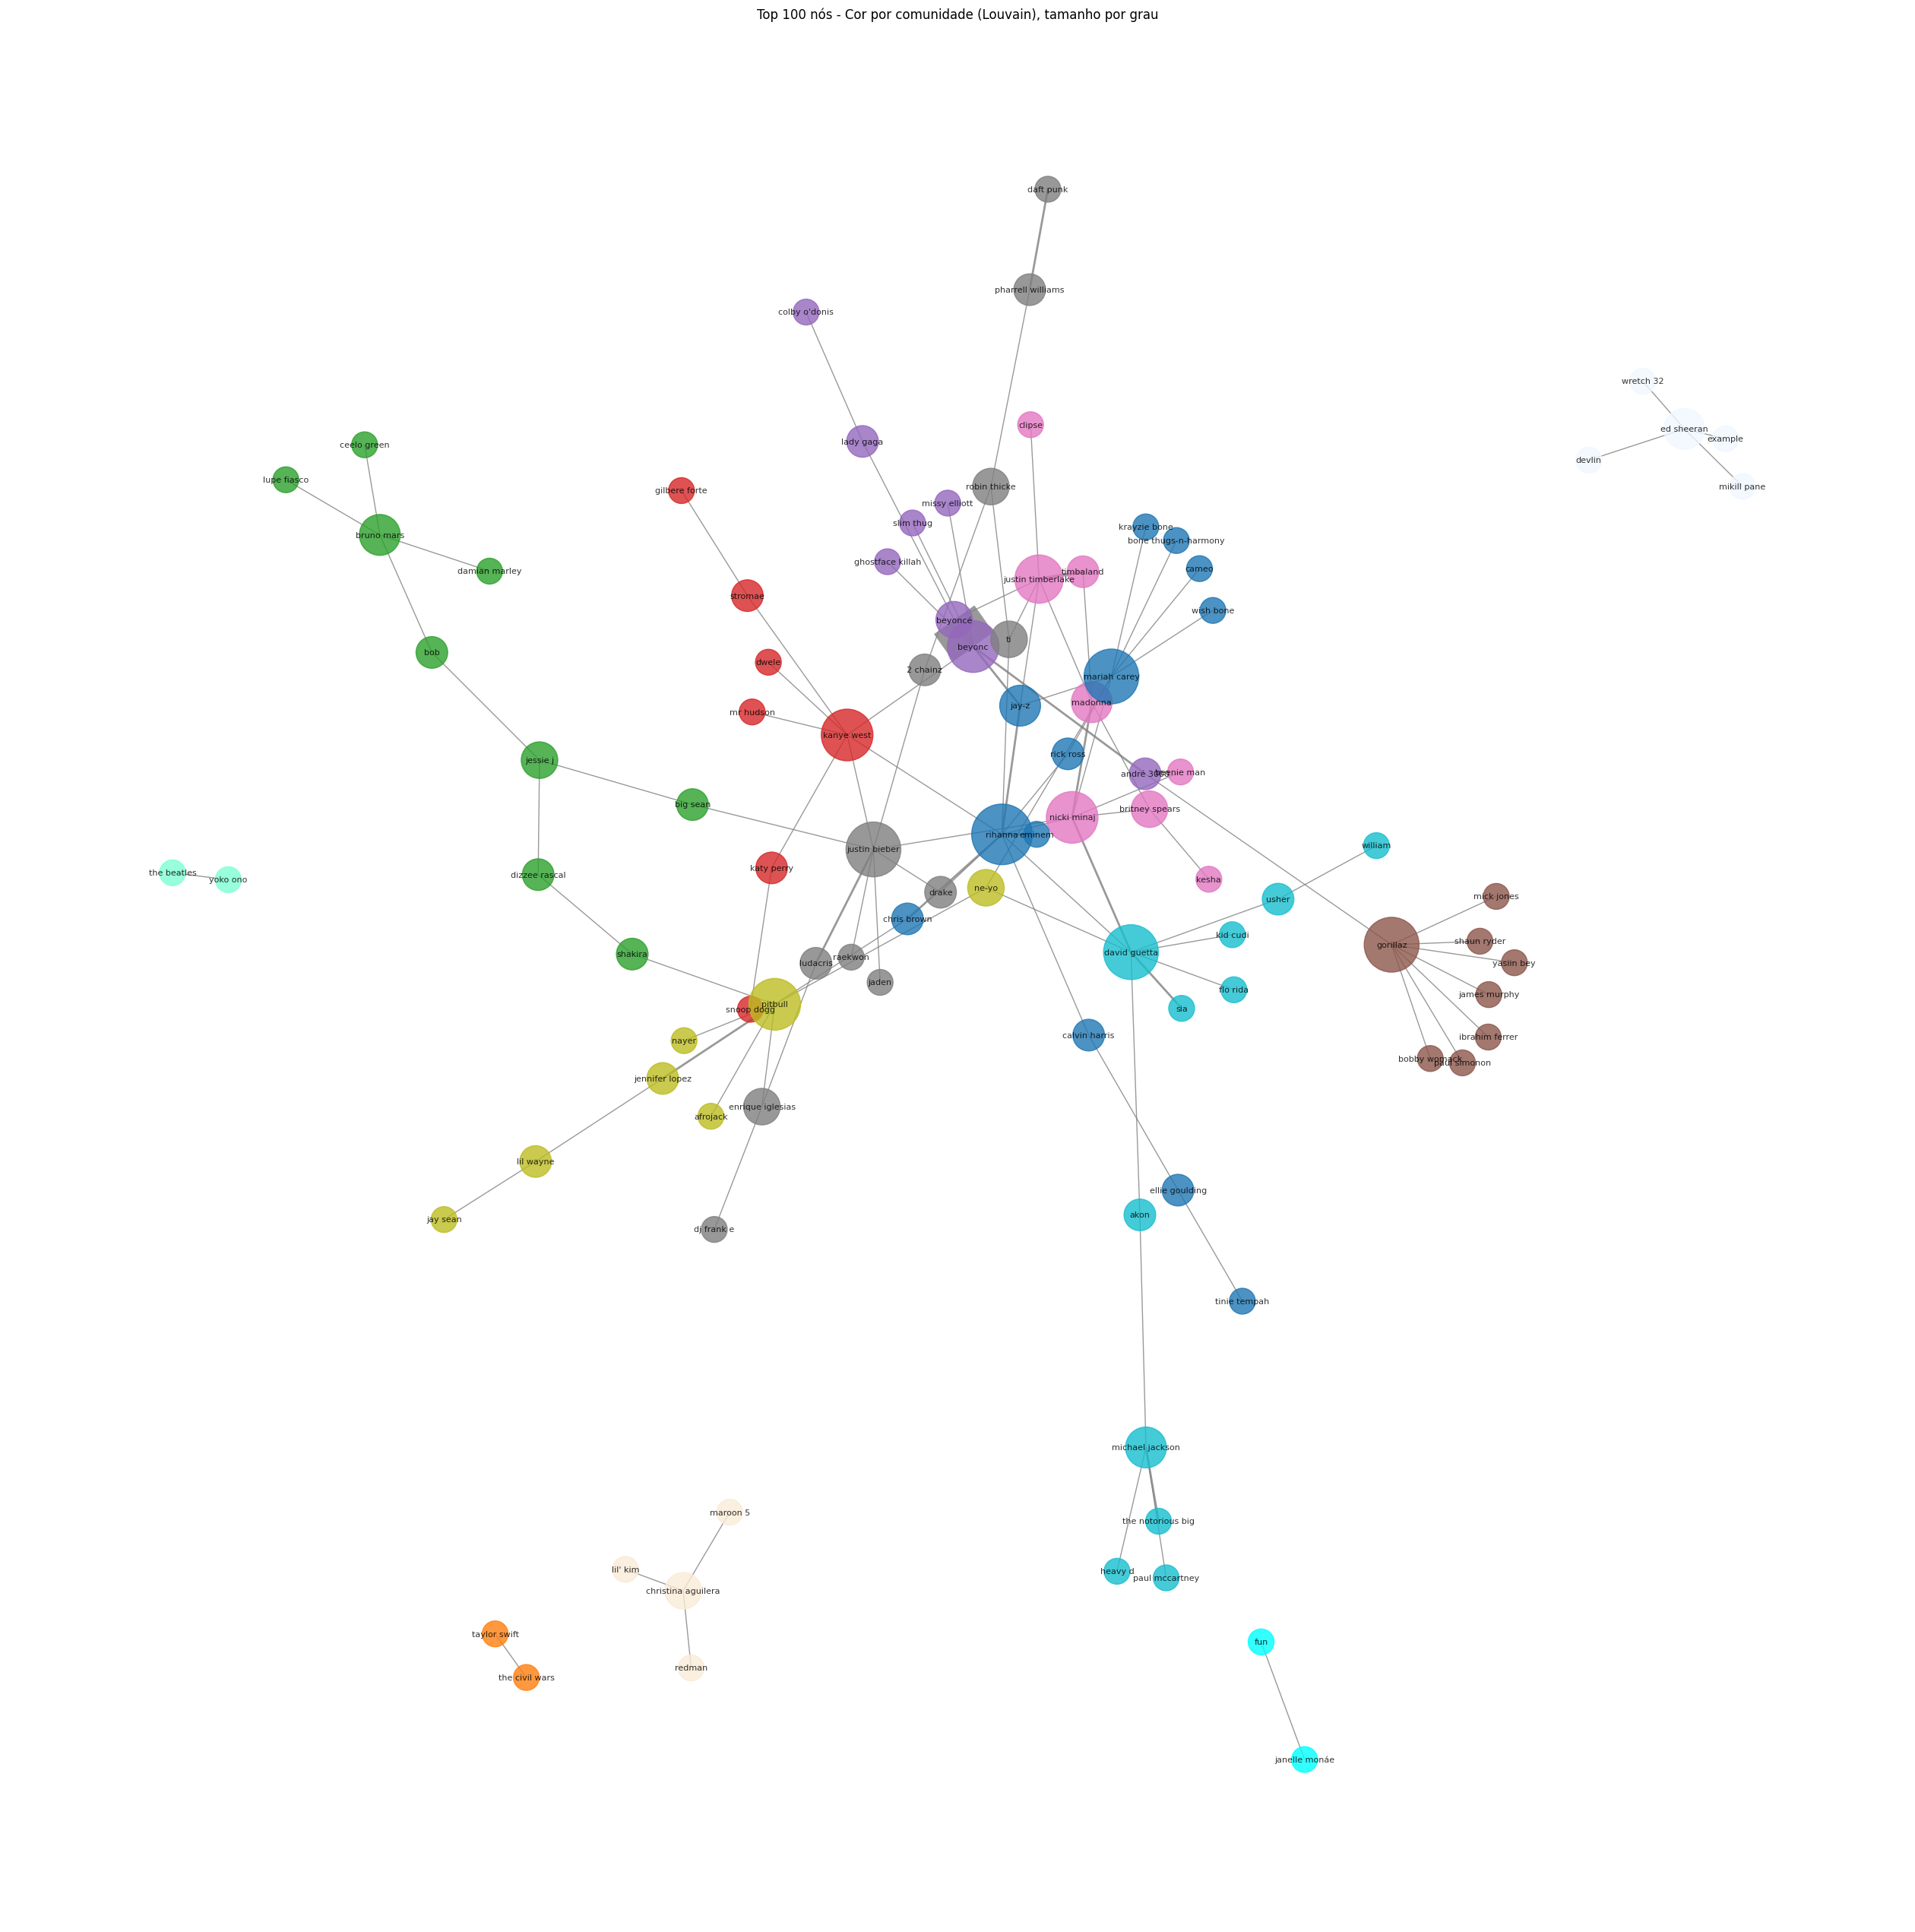


Total de comunidades (Louvain) detectadas: 14

Comunidade 8 (tamanho 12): ['big boi', 'big rube', 'ceelo green', 'common', 'erykah badu', 'j cole', 'janelle mone', 'janelle monáe', 'kendrick lamar', 'miguel', 'outkast', 'sleepy brown']
Comunidade 1 (tamanho 17): ['alicia keys', 'chance the rapper', 'chris brown', 'drake', 'james blake', 'juelz santana', 'justin bieber', 'justin timberlake', 'kelly rowland', 'kevin mccall', 'lil wayne', 'nicki minaj', 'rihanna', 'the weeknd', 'tinashe', 'trey songz', 'tyga']
Comunidade 3 (tamanho 7): ['carlos santana', "d'angelo", 'keyshia cole', 'lauryn hill', "lil' kim", 'mary j blige', 'missy elliott']
Comunidade 4 (tamanho 8): ['ariana grande', 'childish gambino', 'gucci mane', 'hope', 'jhen aiko', 'jhené aiko', 'k roosevelt', 'lite']
Comunidade 5 (tamanho 2): ['lisa left eye lopes', 'tlc']
Comunidade 6 (tamanho 14): ['boo & gotti', 'jagged edge', 'jermaine dupri', 'juicy j', 'kanye west', 'lil jon', 'pitbull', 'r kelly', 'rev run', 'shyne', 't-pai

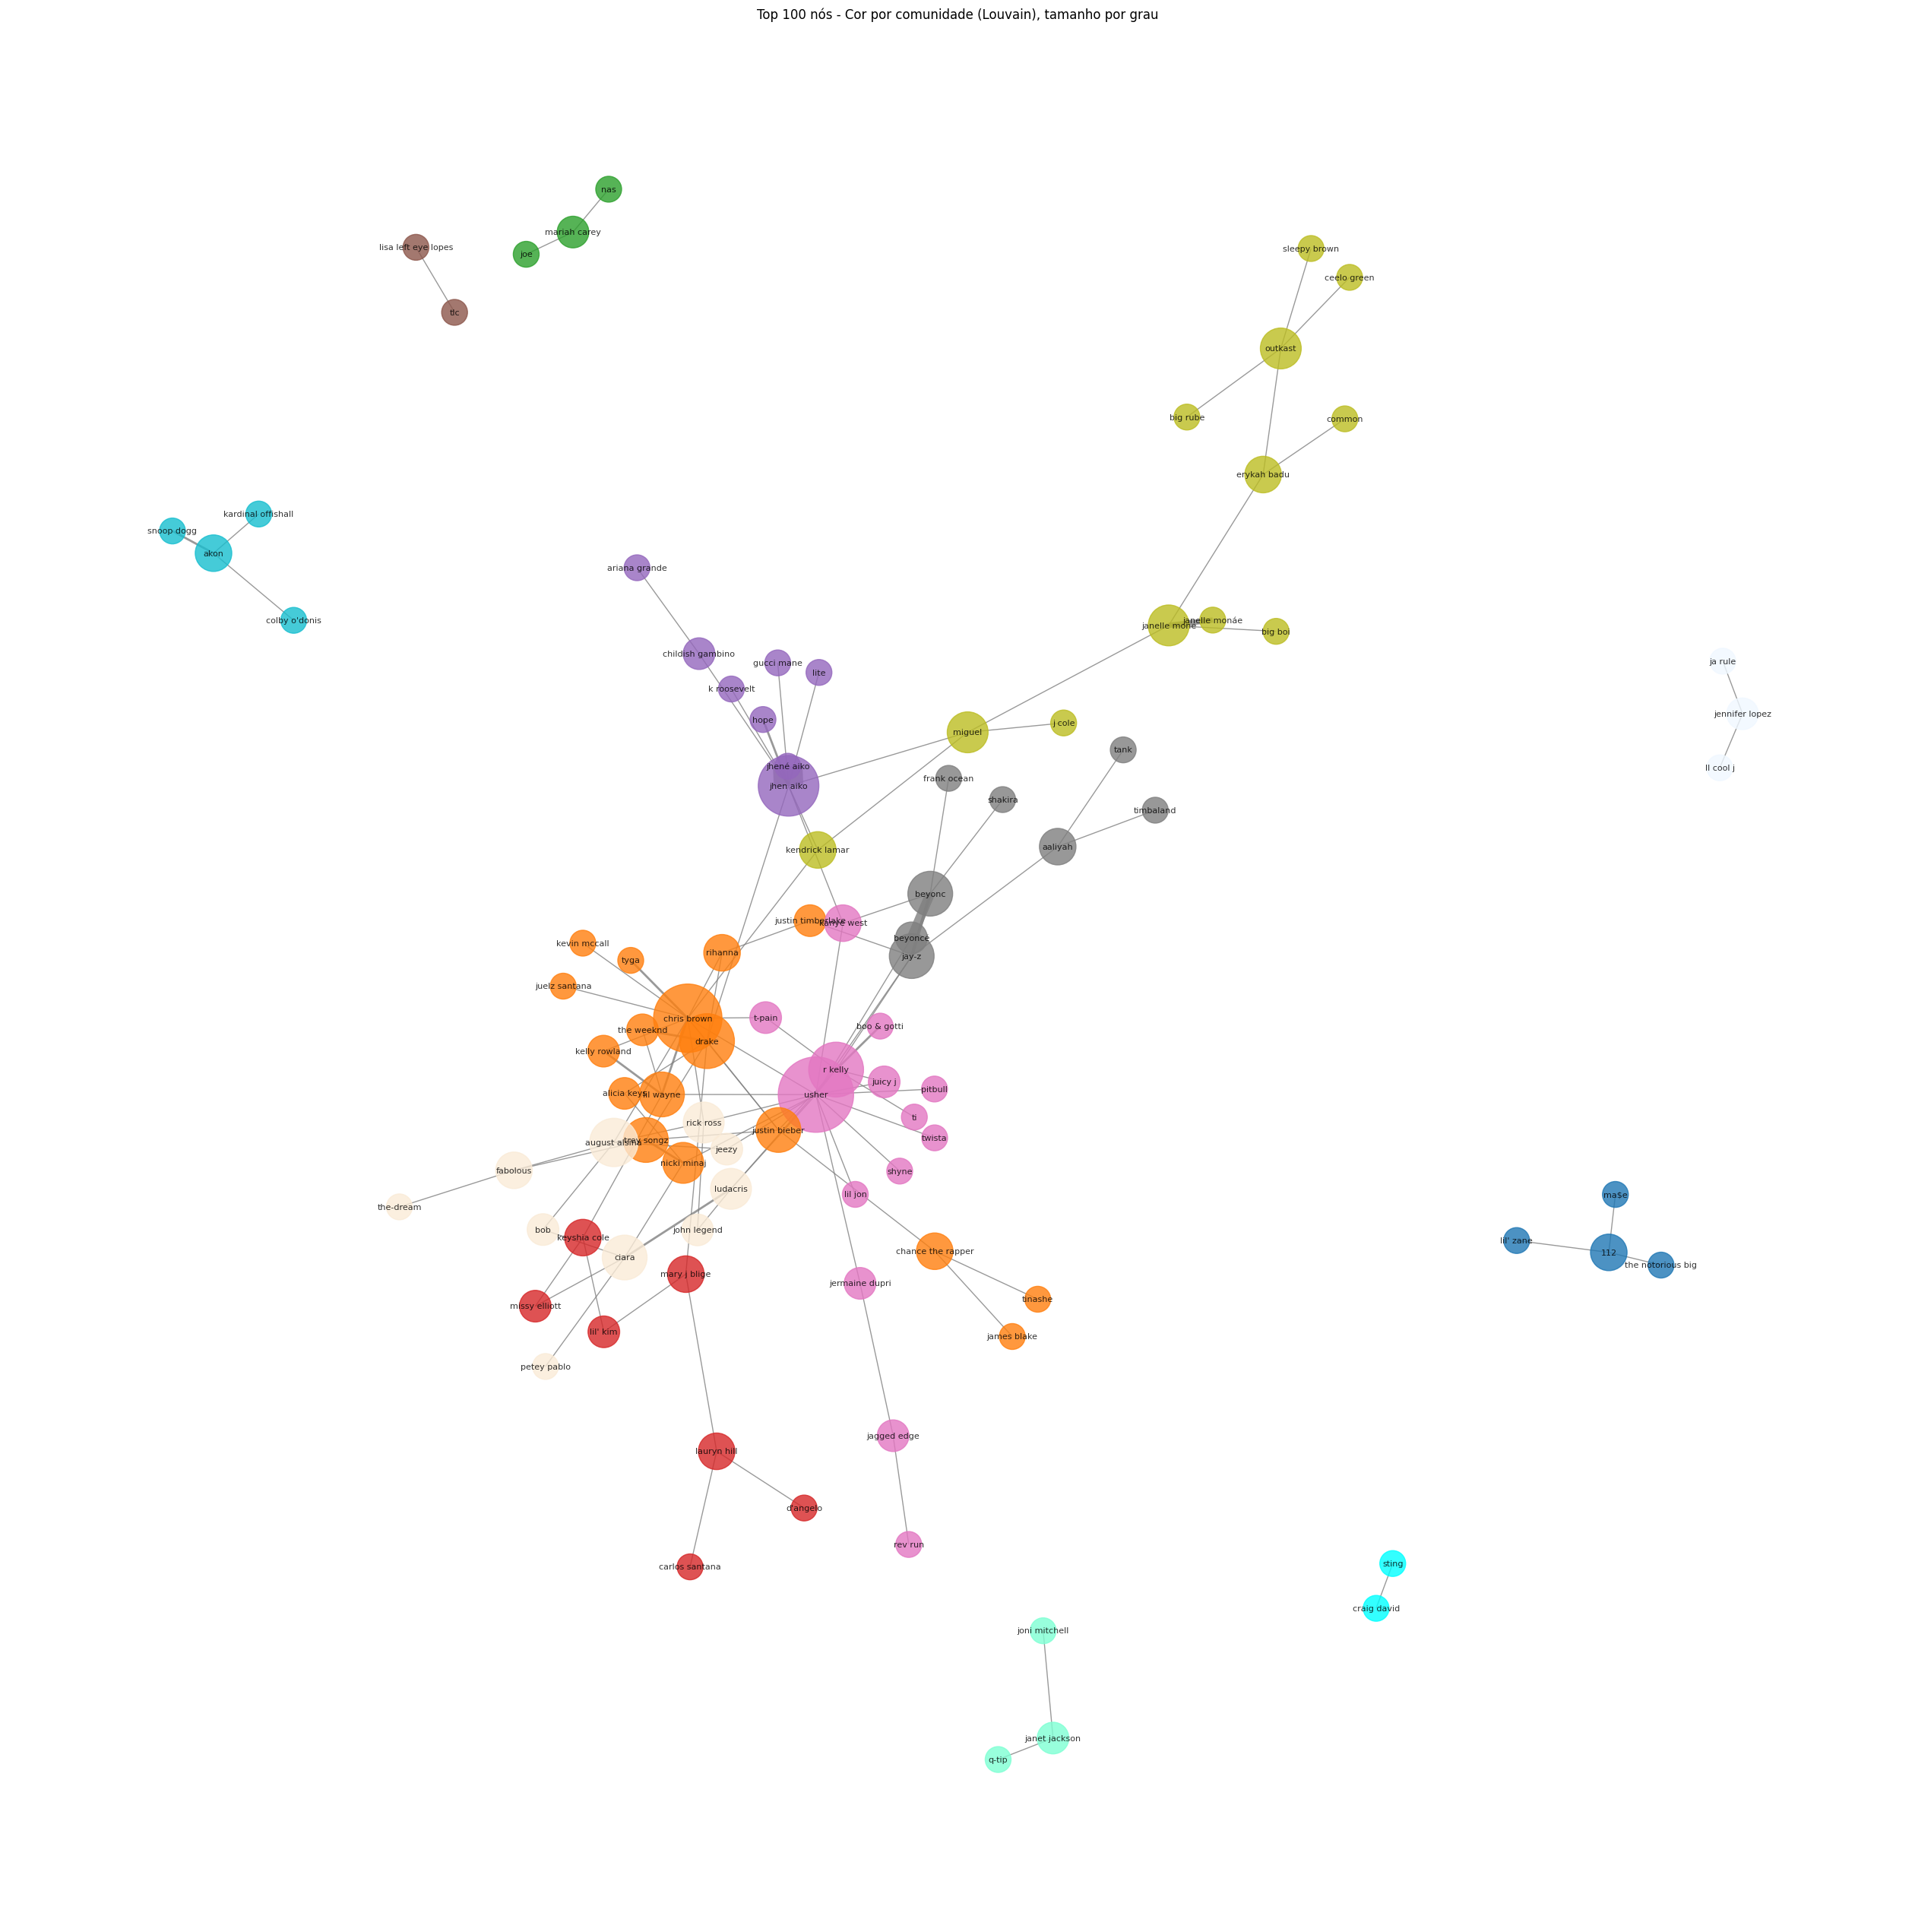


Total de comunidades (Louvain) detectadas: 7

Comunidade 1 (tamanho 2): ['kid rock', 'sheryl crow']
Comunidade 3 (tamanho 4): ['colbie caillat', 'ed sheeran', 'gary lightbody', 'taylor swift']
Comunidade 6 (tamanho 3): ['alison krauss', 'brad paisley', 'll cool j']
Comunidade 0 (tamanho 2): ['blake shelton', 'pistol annies']
Comunidade 2 (tamanho 2): ['florida georgia line', 'nelly']
Comunidade 4 (tamanho 2): ['jimmy buffett', 'zac brown band']
Comunidade 5 (tamanho 3): ['elvis presley', 'millie kirkham', 'the jordanaires']
Modularidade da partição Louvain: 0.8264
====== MÉTRICAS DE ANÁLISE DA REDE ======

🔹 Top Degree Centrality:
taylor swift: 0.1765
brad paisley: 0.1176
elvis presley: 0.1176
kid rock: 0.0588
sheryl crow: 0.0588
ed sheeran: 0.0588
gary lightbody: 0.0588
alison krauss: 0.0588
colbie caillat: 0.0588
blake shelton: 0.0588

🔹 Top Betweenness Centrality:
taylor swift: 0.0221
brad paisley: 0.0074
elvis presley: 0.0074
kid rock: 0.0000
sheryl crow: 0.0000
ed sheeran: 0.0000

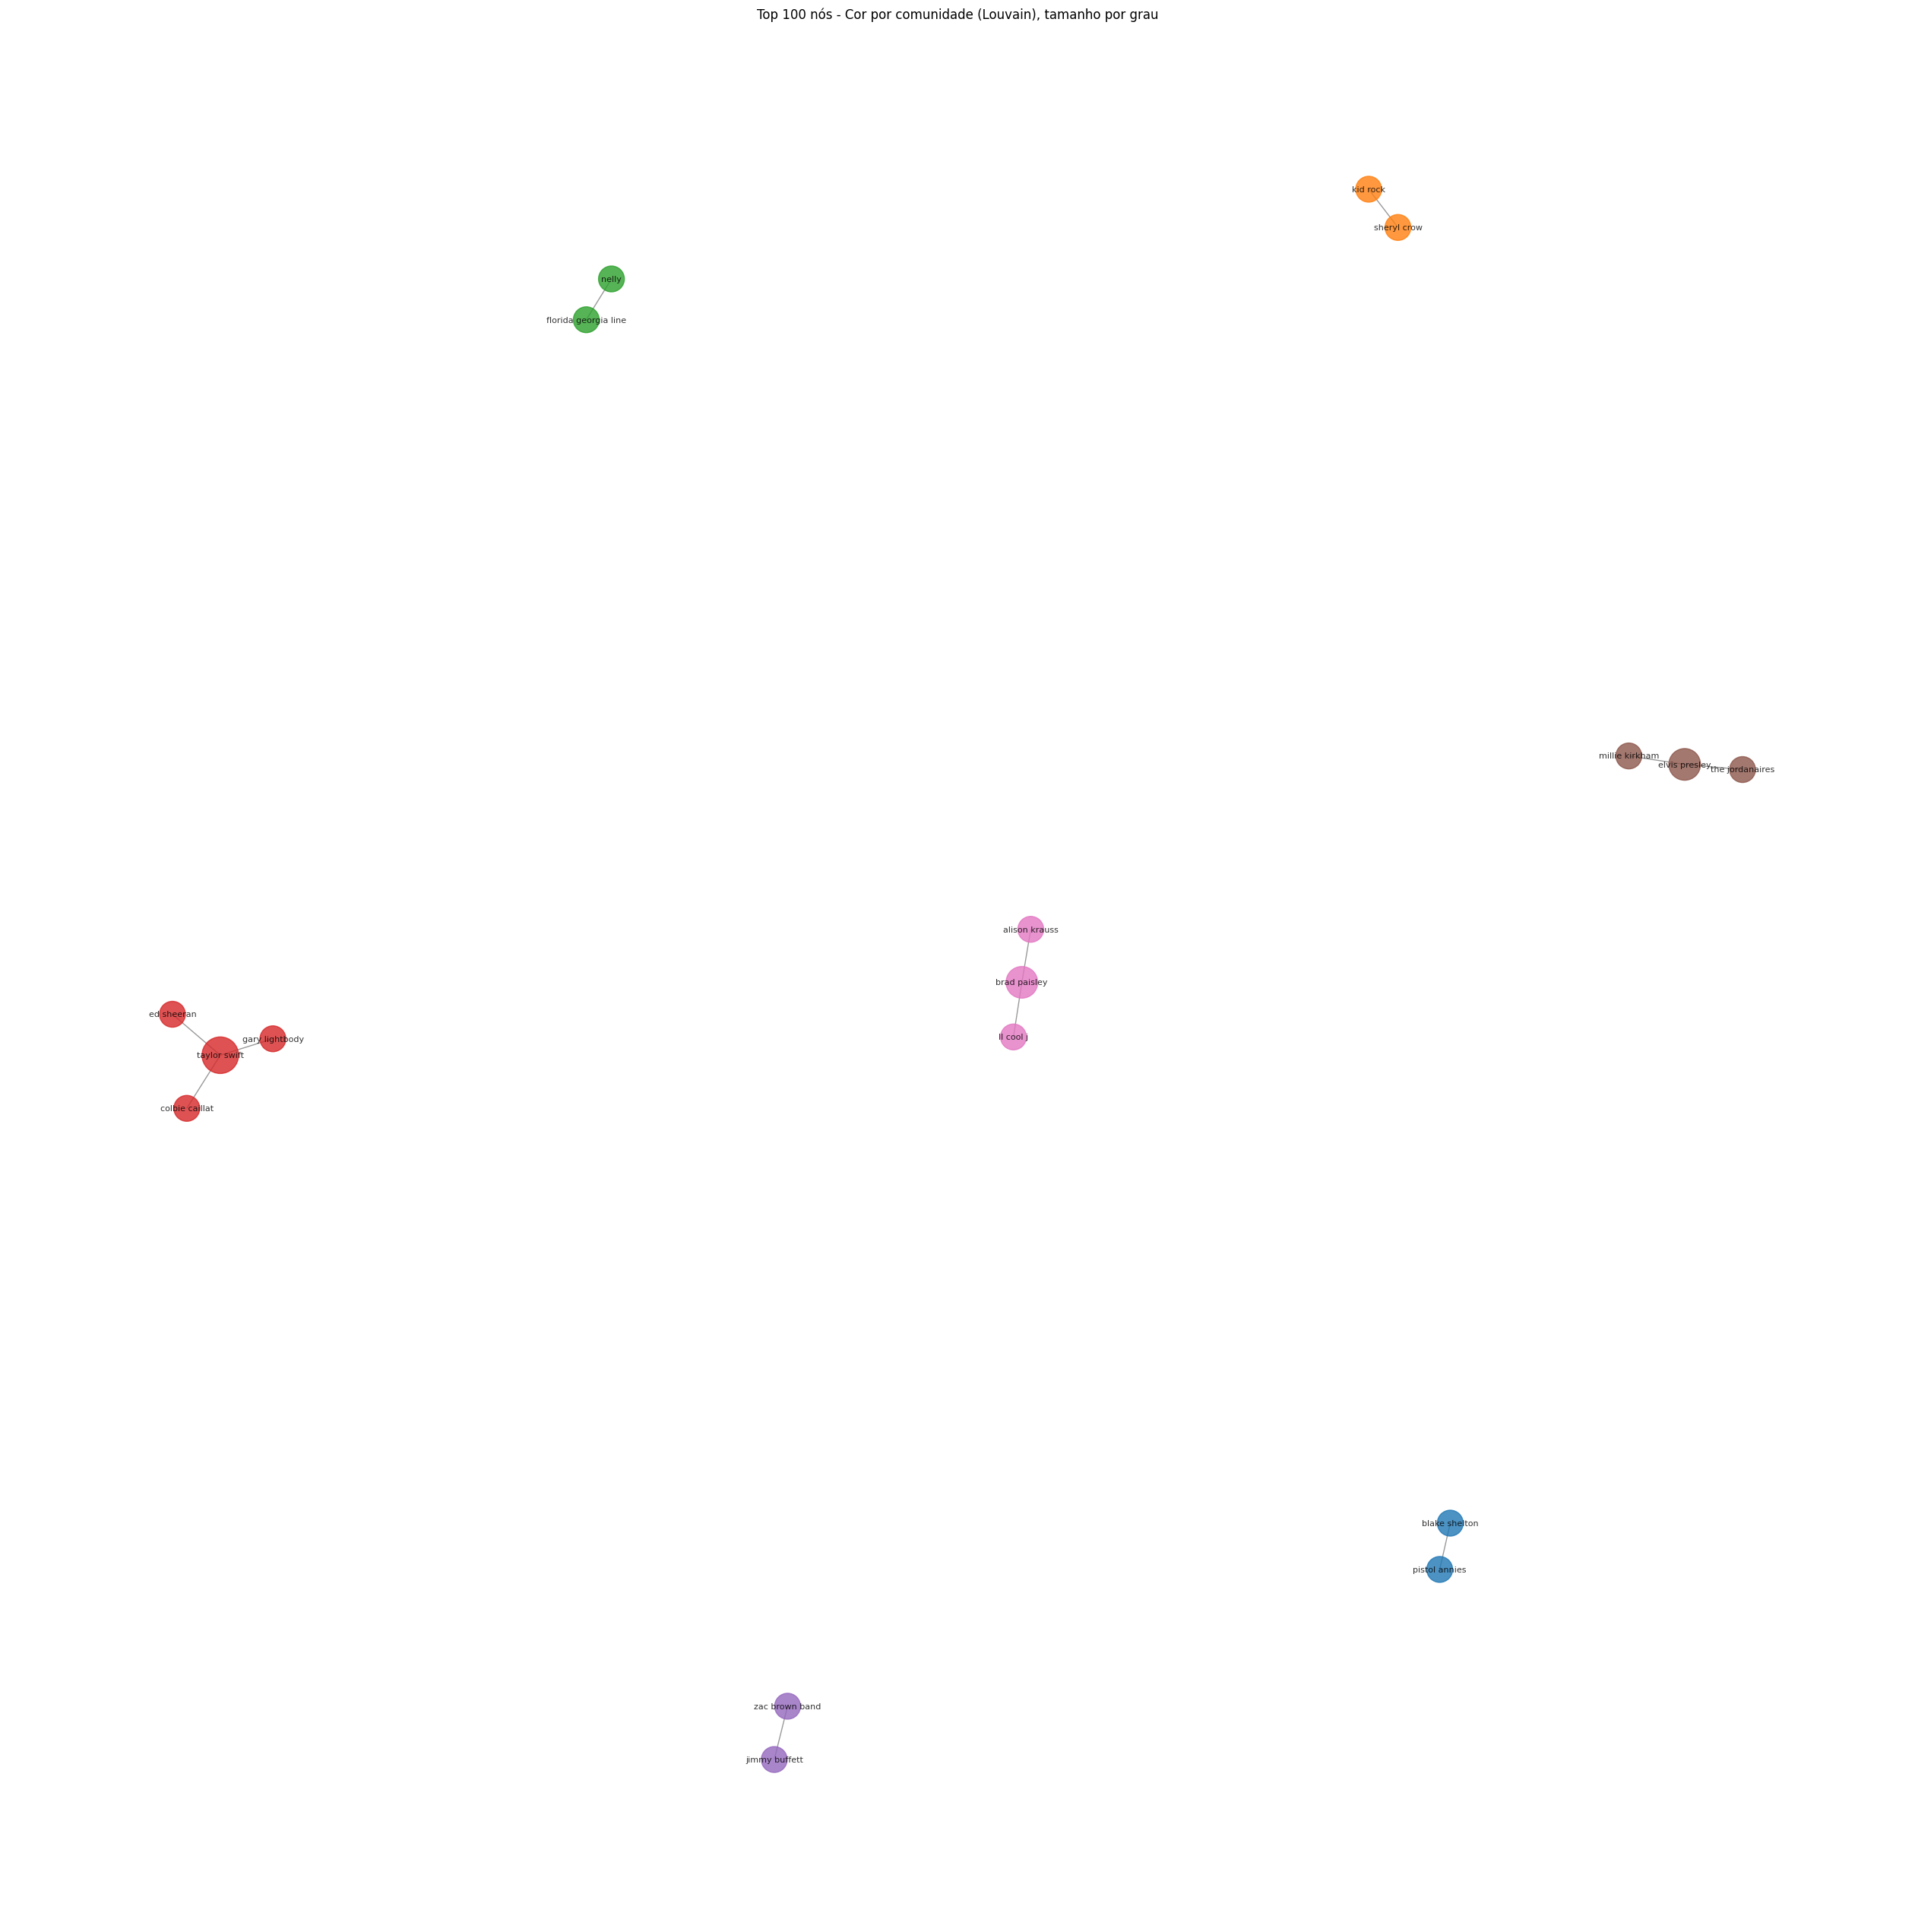


Total de comunidades (Louvain) detectadas: 19

Comunidade 1 (tamanho 2): ['janelle mone', 'janelle monáe']
Comunidade 3 (tamanho 2): ['frank ocean', 'james fauntleroy']
Comunidade 5 (tamanho 2): ['lil wayne', 'nicki minaj']
Comunidade 6 (tamanho 2): ['del the funky homosapien', 'gorillaz']
Comunidade 8 (tamanho 2): ['david bowie', 'john lennon']
Comunidade 10 (tamanho 2): ['coldplay', 'jay-z']
Comunidade 13 (tamanho 2): ['maynard james keenan', 'rage against the machine']
Comunidade 14 (tamanho 2): ['m83', 'zola jesus']
Comunidade 16 (tamanho 2): ['desire', 'wzrd']
Comunidade 15 (tamanho 4): ['jeremy mckinnon', 'kellin quinn', 'pierce the veil', 'vanessa harris']
Comunidade 11 (tamanho 3): ['clare torry', 'pink floyd', 'roy harper']
Comunidade 12 (tamanho 2): ['los incas', 'simon & garfunkel']
Comunidade 17 (tamanho 2): ['ladysmith black mambazo', 'paul simon']
Comunidade 18 (tamanho 3): ['nolen strals', 'okey canfield chenoweth iii', 'titus andronicus']
Comunidade 0 (tamanho 2): ['bi

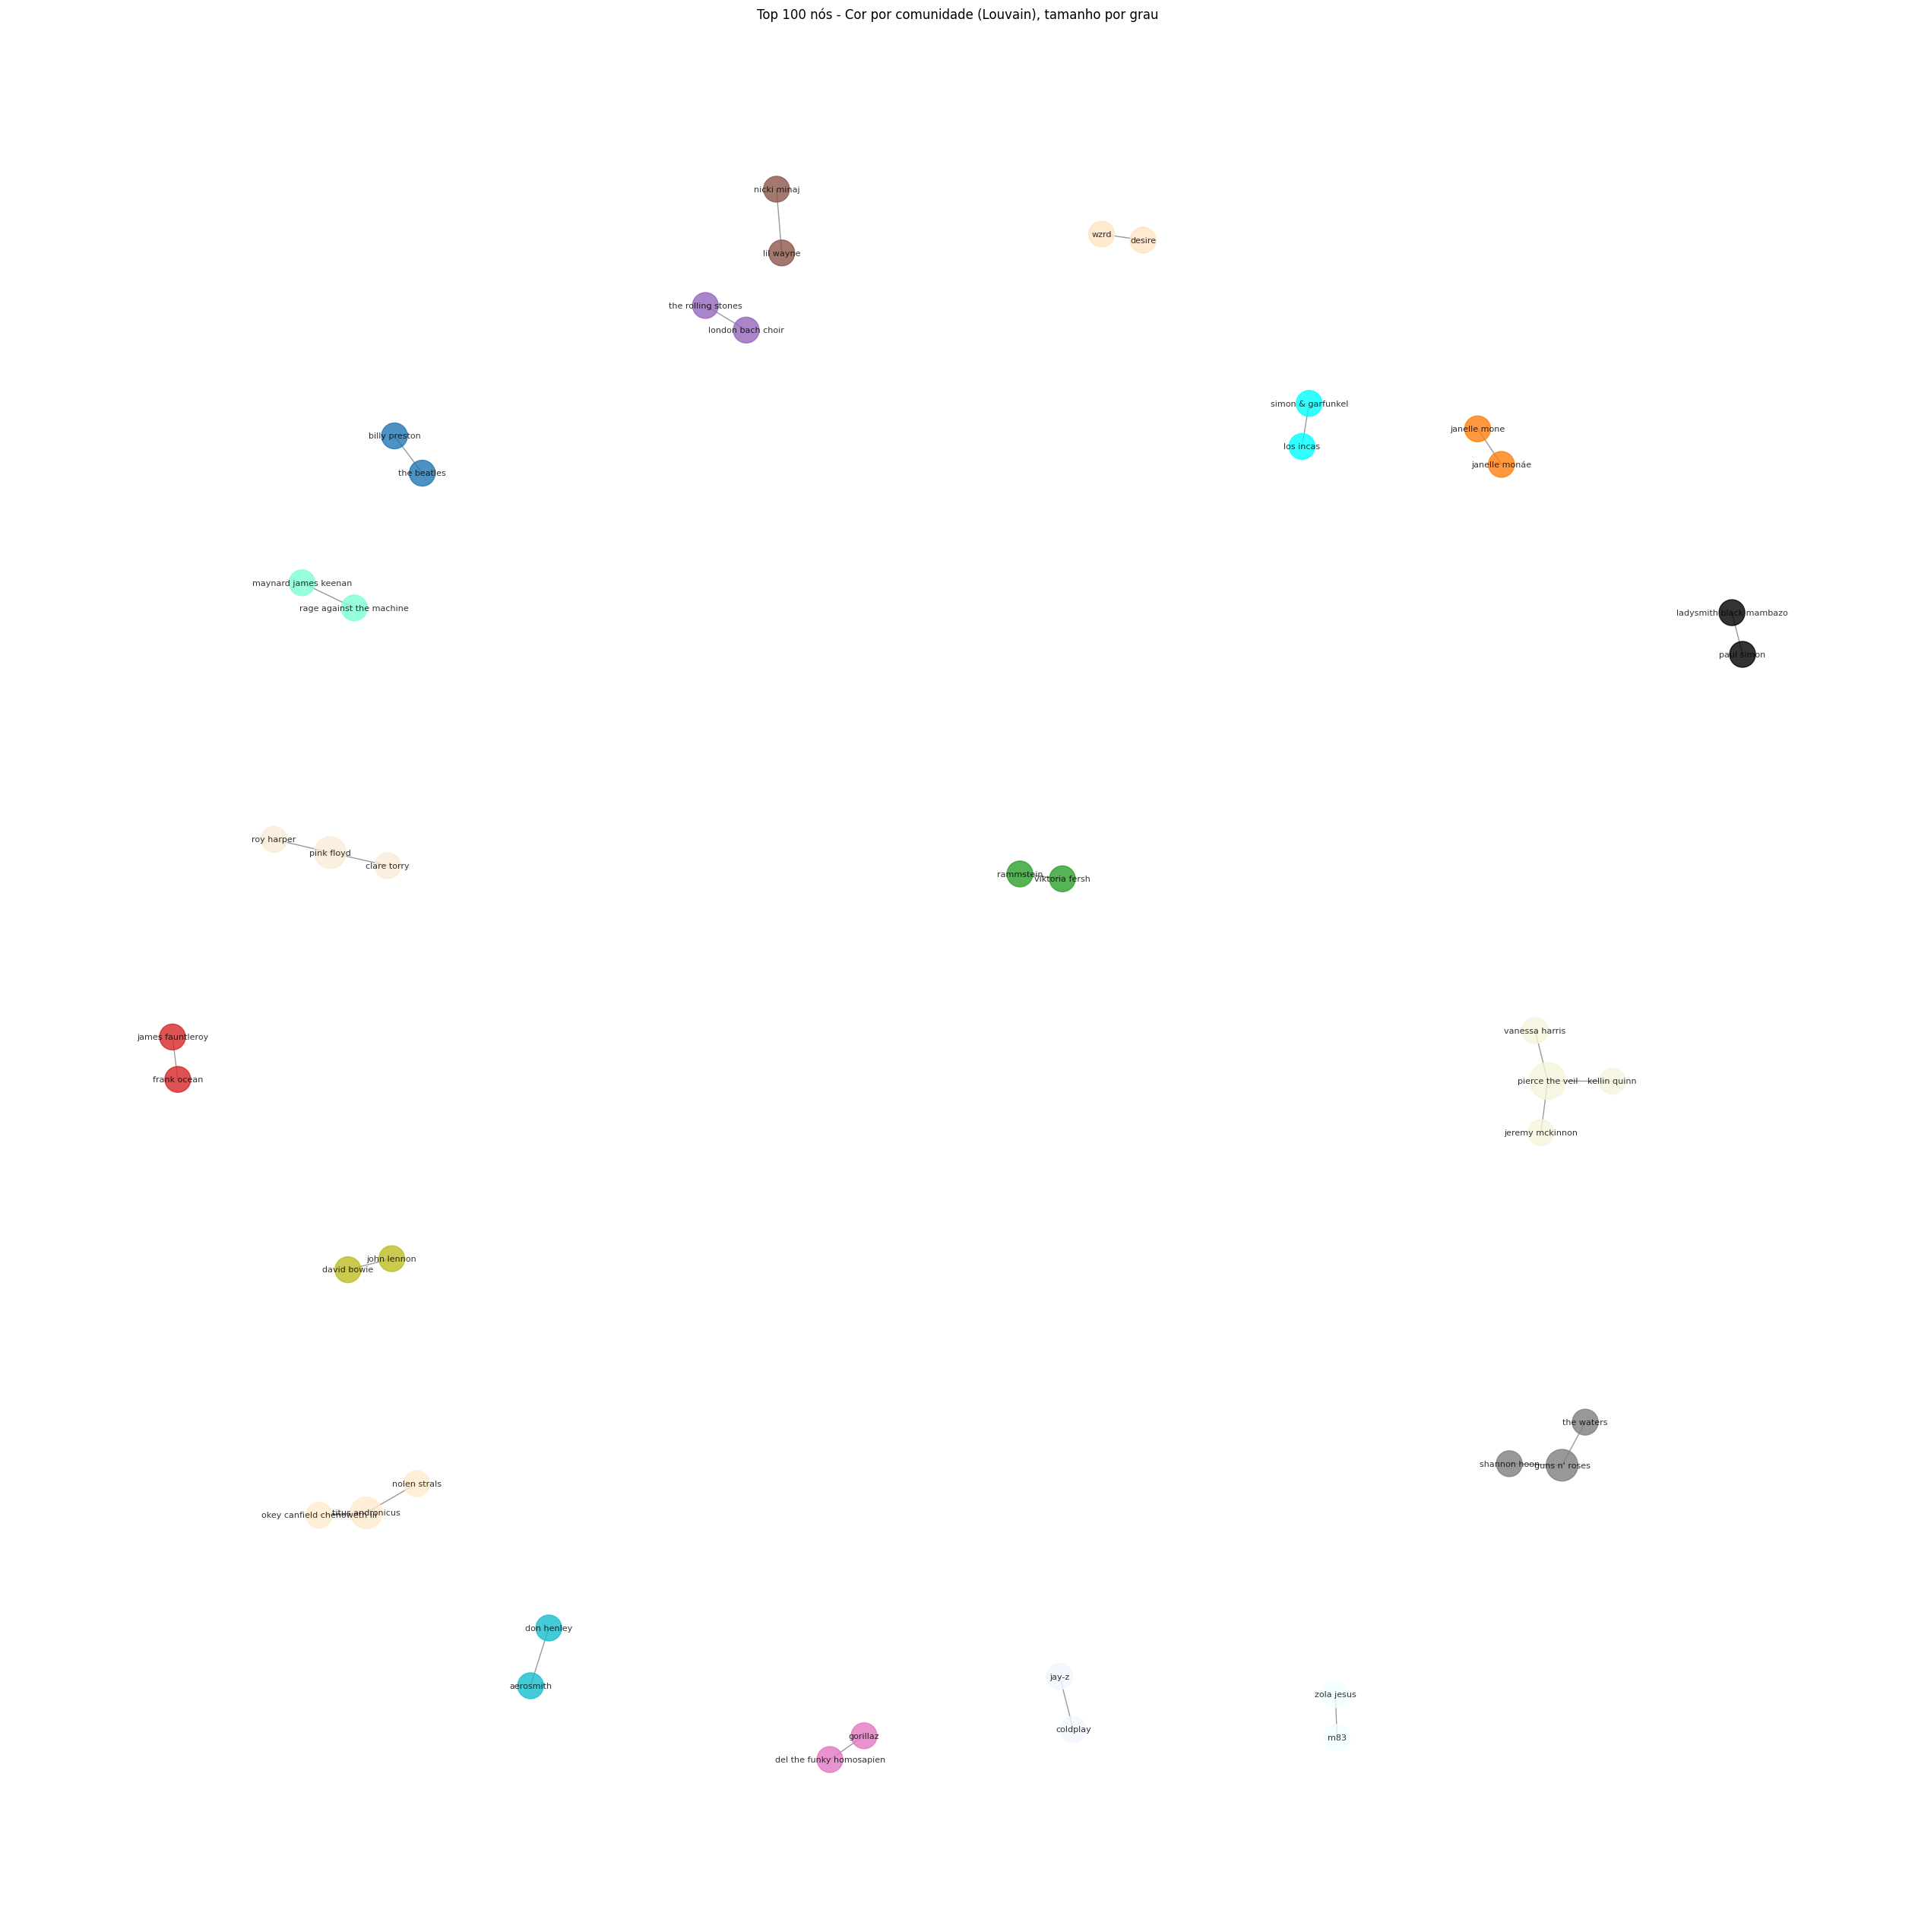


Total de comunidades (Louvain) detectadas: 13

Comunidade 0 (tamanho 6): ['atban klann', 'buc fifty', 'dresta', 'eazy-e', 'menajahtwa', 'rudy ray moore']
Comunidade 1 (tamanho 8): ['j cole', 'jeff bhasker', 'kid cudi', 'lloyd', 'marsha ambrosius', 'mary j blige', 'melanie fiona', 'wale']
Comunidade 8 (tamanho 8): ['birdman', 'chris brown', 'drake', 'fabolous', 'freeway', 'kevin mccall', 'lil wayne', 'nicki minaj']
Comunidade 2 (tamanho 19): ['50 cent', 'akon', 'bone thugs-n-harmony', 'ca$his', 'daz dillinger', 'denaun', 'dominic west', 'dr dre', 'eminem', 'hittman', 'j-black', 'kurupt', 'masta ace', 'obie trice', 'rell', "royce da 5'9", 'six2', 'snoop dogg', 'tha dogg pound']
Comunidade 5 (tamanho 2): ['gang starr', 'scarface']
Comunidade 6 (tamanho 2): ['de la soul', 'gorillaz']
Comunidade 11 (tamanho 10): ['amil', 'beanie sigel', 'foxy brown', 'ja rule', 'jay-z', 'jeezy', 'juicy j', 'rick ross', 't-pain', 'wiz khalifa']
Comunidade 10 (tamanho 6): ['2pac', 'bad azz', 'dido', 'nate do

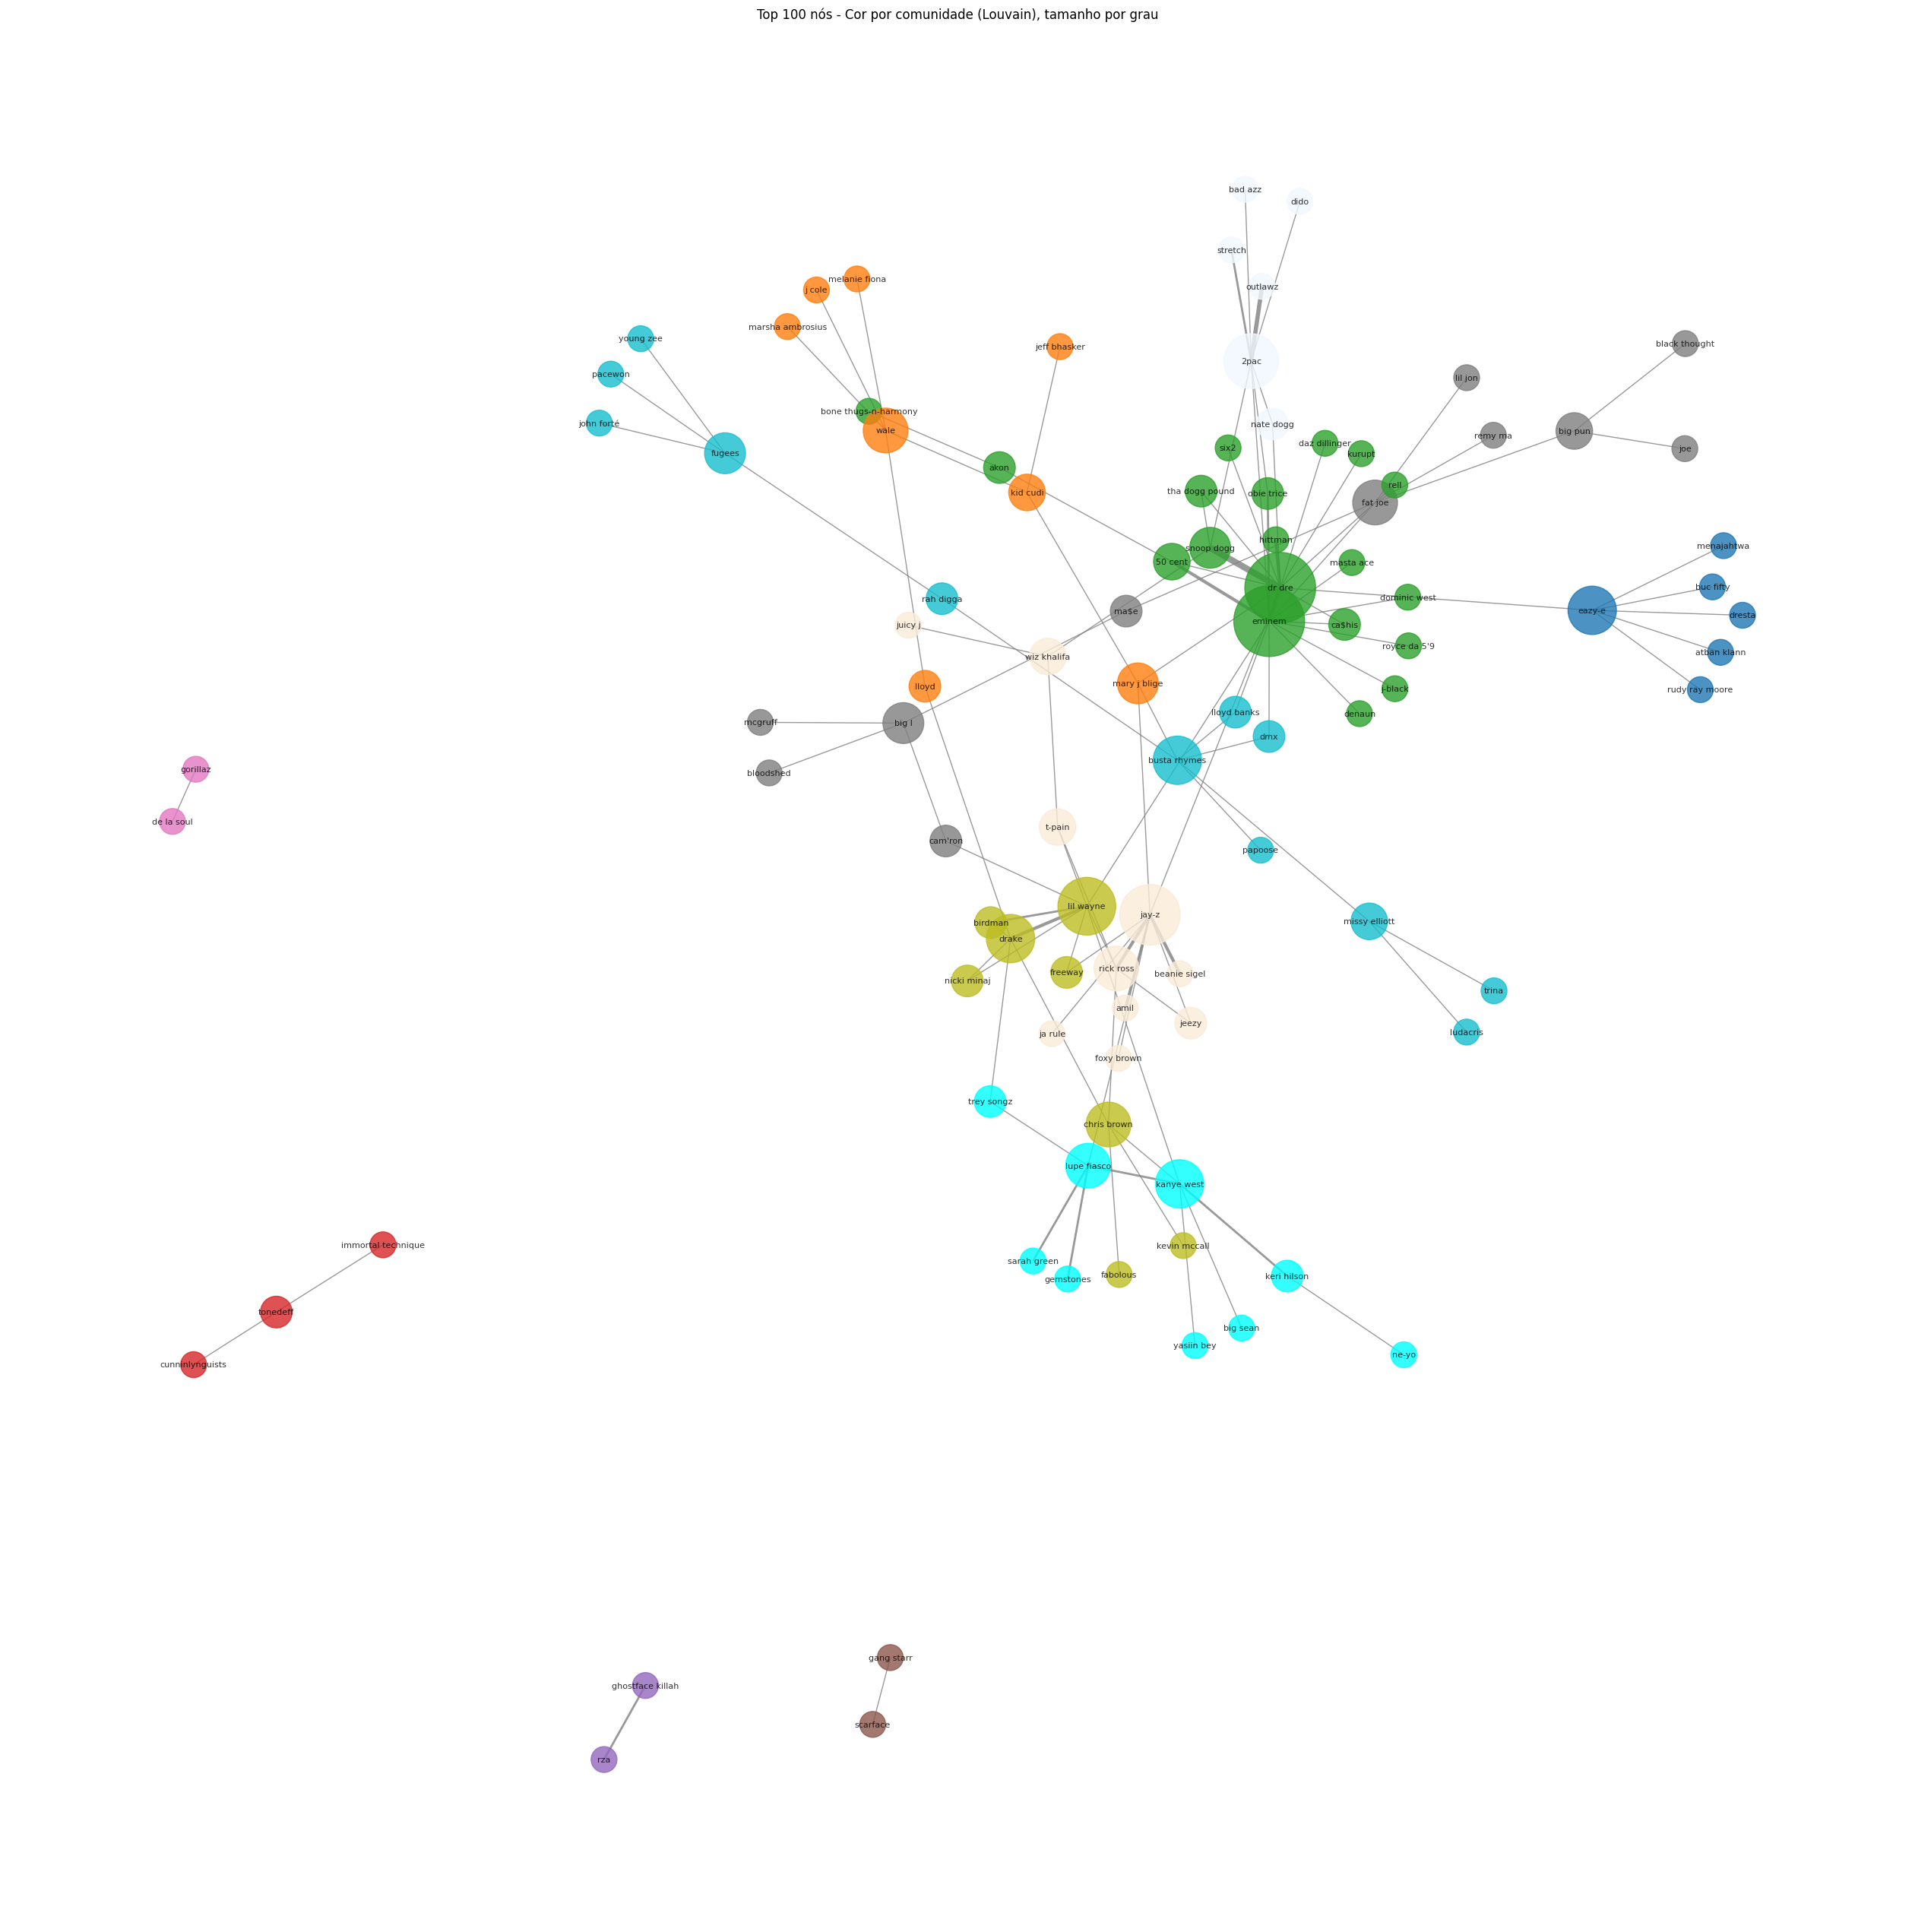

In [ ]:
import re
import networkx as nx
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
from networkx.algorithms import community
from networkx.algorithms.community import label_propagation_communities
from networkx.algorithms.community import greedy_modularity_communities
from networkx.algorithms.community import modularity


def grafo_tag(df_analisado, top_number = 100):
  # ======== Funções de limpeza de nomes ========
  def normalize_whitespace(s: str) -> str:
      return re.sub(r'\s+', ' ', s).strip()

  def strip_parentheses(name: str) -> str:
      return normalize_whitespace(re.sub(r'\s*\(.*?\)', '', name))

  def normalize_artist_name(name: str) -> str:
      # Nome minúsculo, sem espaços excessivos, sem parênteses
      return strip_parentheses(name).lower()

  def parse_features(features_str: str) -> list[str]:
      inner = features_str.strip()[1:-1]
      pattern = re.compile(r'"(.*?)"|\'(.*?)\'|([^,]+)')
      names = []
      for m in pattern.finditer(inner):
          raw = m.group(1) or m.group(2) or m.group(3)
          raw = raw.replace('\\$', '$').replace('\\', '')
          clean = normalize_whitespace(raw)
          if clean:
              names.append(clean)
      return names

  def extract_collaborators(artist: str, features: list) -> list[str]:
      artist_base = normalize_artist_name(artist)
      if not isinstance(features, list):
          return []
      return [name for name in features if normalize_artist_name(name) != artist_base]

  # ======== Construção do grafo ========
  G = nx.Graph()

  for row in df_analisado.itertuples(index=False):
      artista_raw = row.artist
      collabs_raw = extract_collaborators(artista_raw, row.features)

      artista = normalize_artist_name(artista_raw)
      collabs = [normalize_artist_name(c) for c in collabs_raw]

      for c in collabs:
          if G.has_edge(artista, c):
              G[artista][c]['weight'] += 1
          else:
              G.add_edge(artista, c, weight=1)

  # Remove nós isolados
  G.remove_nodes_from(list(nx.isolates(G)))

  # ======== Plotagem: apenas top nós por grau ========
  # Top por grau
  # top_number = 100
  top = sorted(G.degree, key=lambda x: x[1], reverse=True)[:top_number]
  top_nodes = [n for n, _ in top]
  subG = G.subgraph(top_nodes).copy()
  subG.remove_nodes_from(list(nx.isolates(subG)))

  # ======== Detecção de comunidades com Louvain ========
  partition_louvain = community_louvain.best_partition(subG, weight='weight')

  # Agrupar os nós por comunidade
  comunidades_subG = {}
  for node, com_id in partition_louvain.items():
      comunidades_subG.setdefault(com_id, []).append(node)

  # Exibe cada comunidade
  print(f"\nTotal de comunidades (Louvain) detectadas: {len(comunidades_subG)}\n")
  for com_id, nodes in comunidades_subG.items():
      print(f"Comunidade {com_id} (tamanho {len(nodes)}): {sorted(nodes)}")

  # Primeiro transforma o particionamento Louvain (dicionário) em lista de sets:
  partition_list = []
  for comm_id in set(partition_louvain.values()):
      members = {node for node, cid in partition_louvain.items() if cid == comm_id}
      partition_list.append(members)

  # Calcula a modularidade da solução
  mod_score = modularity(subG, partition_list, weight='weight')
  print(f"Modularidade da partição Louvain: {mod_score:.4f}")

  # ======== Cores por comunidade ========
  # Mapeia cada nó -> id da comunidade
  comunidade_por_no = partition_louvain

  # Monta paleta suficiente de cores
  base_cores = list(mcolors.TABLEAU_COLORS.values())
  if len(comunidades_subG) > len(base_cores):
      base_cores += list(mcolors.CSS4_COLORS.values())
  cores_disponiveis = base_cores

  # Define cor de cada nó segundo a comunidade
  node_colors = [
      cores_disponiveis[comunidade_por_no[n] % len(cores_disponiveis)]
      for n in subG.nodes()
  ]

  # Tamanho dos nós proporcional ao grau
  node_sizes = [300 + 300 * subG.degree(n) for n in subG.nodes()]

  # Layout
  pos = nx.spring_layout(subG, k=0.15, seed=42)

  # Labels escapados para evitar problemas com matplotlib
  escaped_labels = {node: node.replace('$', r'\$') for node in subG.nodes()}

  def analisar_metrica_rede(G, top_k=10):
      print("====== MÉTRICAS DE ANÁLISE DA REDE ======")

      if G.number_of_nodes() == 0 or G.number_of_edges() == 0:
          print("Grafo vazio ou sem arestas. Nada a analisar.")
          return

      # Degree Centrality
      deg_c = nx.degree_centrality(G)
      top_deg = sorted(deg_c.items(), key=lambda x: x[1], reverse=True)[:top_k]
      print("\n🔹 Top Degree Centrality:")
      for node, val in top_deg:
          print(f"{node}: {val:.4f}")

      # Betweenness Centrality
      btw_c = nx.betweenness_centrality(G, weight='weight')
      top_btw = sorted(btw_c.items(), key=lambda x: x[1], reverse=True)[:top_k]
      print("\n🔹 Top Betweenness Centrality:")
      for node, val in top_btw:
          print(f"{node}: {val:.4f}")

      # Closeness Centrality
      clo_c = nx.closeness_centrality(G)
      top_clo = sorted(clo_c.items(), key=lambda x: x[1], reverse=True)[:top_k]
      print("\n🔹 Top Closeness Centrality:")
      for node, val in top_clo:
          print(f"{node}: {val:.4f}")

      # Shortest Path Length
      if nx.is_connected(G):
          avg_path = nx.average_shortest_path_length(G, weight='weight')
          print(f"\n🔹 Average shortest path length: {avg_path:.4f}")
      else:
          # Componente gigante
          largest_cc = max(nx.connected_components(G), key=len)
          subG_largest = G.subgraph(largest_cc)
          avg_path = nx.average_shortest_path_length(subG_largest, weight='weight')
          print(f"\n🔹 Average shortest path length (maior componente): {avg_path:.4f}")

      # Assortativity
      assortativity = nx.degree_pearson_correlation_coefficient(G)
      print(f"\n🔹 Assortativity coefficient (grau vs grau): {assortativity:.4f}")

      # Clustering
      clustering = nx.average_clustering(G, weight='weight')
      print(f"\n🔹 Average clustering coefficient: {clustering:.4f}")

      # Componentes
      n_componentes = nx.number_connected_components(G)
      tam_maior_comp = len(max(nx.connected_components(G), key=len))
      print(f"\n🔹 Componentes conectados: {n_componentes}")
      print(f"🔹 Tamanho da maior componente: {tam_maior_comp}")

      print("=========================================\n")

  analisar_metrica_rede(subG)

  # ======== Plot ========
  plt.figure(figsize=(25, 25))
  edge_weights = [subG[u][v]['weight'] for u, v in subG.edges()]
  nx.draw(
      subG,
      pos,
      with_labels=True,
      node_size=node_sizes,
      node_color=node_colors,
      edge_color='gray',
      width=edge_weights,
      font_size=8,
      labels=escaped_labels,
      alpha=0.8
  )
  plt.axis('off')
  plt.title(f"Top {top_number} nós - Cor por comunidade (Louvain), tamanho por grau")
  genero = df_analisado.iloc[0]['tag']
  plt.savefig(f"grafo_colaboracoes_{genero}.pdf", format='pdf', bbox_inches='tight')
  plt.show()

grafo_tag(df_grafo_pop, 100)
grafo_tag(df_grafo_rb, 100)
grafo_tag(df_grafo_country, 100)
grafo_tag(df_grafo_rock, 100)
grafo_tag(df_grafo_rap, 100)

## c) Gerar novas letras de música à partir do conteúdo desta base. Crie um modelo generativo que vai receber o começo de uma letra e gerar o restante da música.

In [ ]:
df_gen = amostras_balanceadas.copy()

In [ ]:
# Apenas músicas com views acima do percentil inferior
porc = 0.1
lim_inf_views = df_gen['views'].quantile(porc)
outliers_views = df_gen[df_gen['views'] < lim_inf_views]
# print_cor(f"Views limite inferior (percentil {porc*100}%): {int(lim_inf_views)}")
# print_cor(f"Num amostras removidas por views abaixo do limite: {len(outliers_views)}")
df_gen = df_gen[df_gen['views'] >= lim_inf_views]

In [ ]:
# Filtro 4: amostras com idioma en
df_gen = amostras_balanceadas.copy()

df_gen = df_gen[df_gen['language'] == 'en'].copy()
print_cor(f"Número de amostras com idioma en: {len(df_gen)}")

Número de amostras com idioma en: 4864


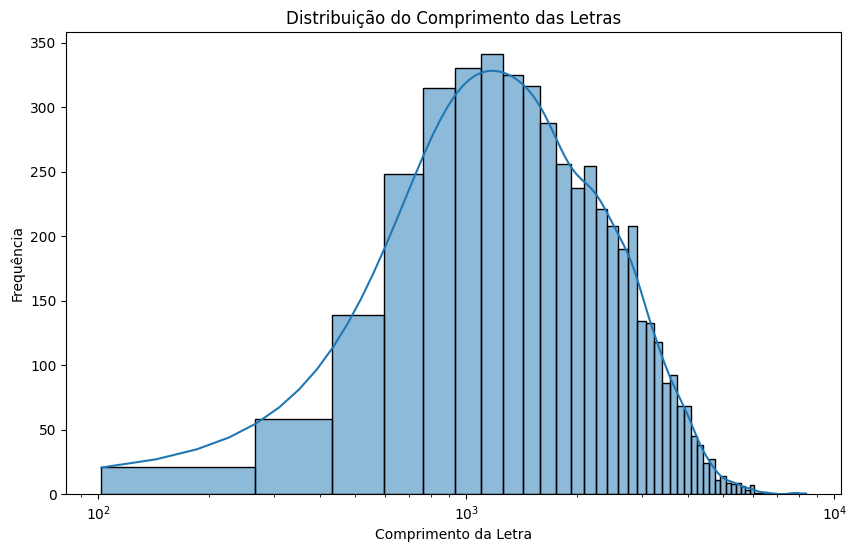

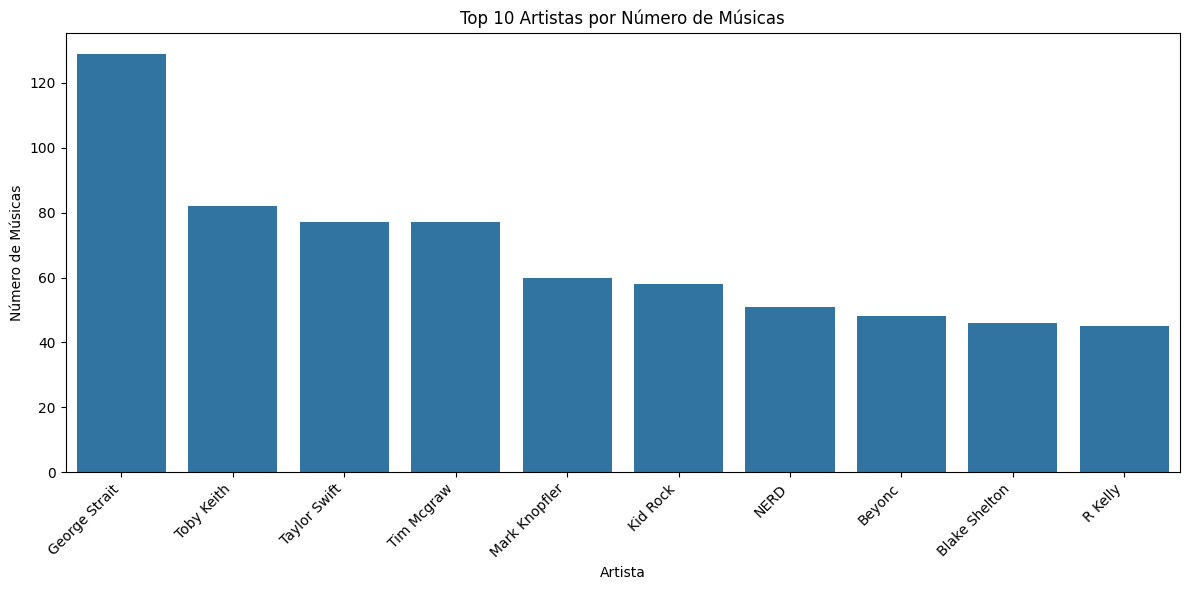

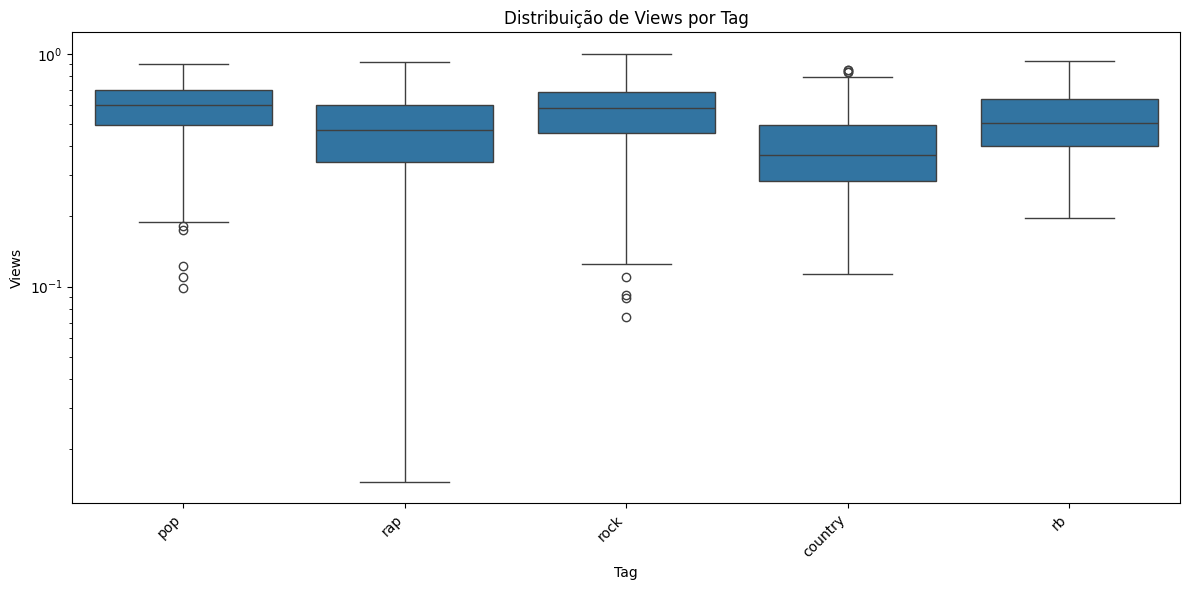

In [ ]:
df_gen['lyrics_length'] = df_gen['lyrics'].apply(len)

# Distribuição de comprimentos de letra
plt.figure(figsize=(10, 6))
sns.histplot(df_gen['lyrics_length'], bins=50, kde=True)
plt.title('Distribuição do Comprimento das Letras')
plt.xlabel('Comprimento da Letra')
plt.ylabel('Frequência')
plt.xscale('log')
plt.show()

# Artistas mais frequentes
plt.figure(figsize=(12, 6))
top_artists = df_gen['artist'].value_counts().head(10)
sns.barplot(x=top_artists.index, y=top_artists.values)
plt.title('Top 10 Artistas por Número de Músicas')
plt.xlabel('Artista')
plt.ylabel('Número de Músicas')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

# Análise de Tags/Gêneros e Views
plt.figure(figsize=(12, 6))
sns.boxplot(x='tag', y='views', data=df_gen)
plt.title('Distribuição de Views por Tag')
plt.xlabel('Tag')
plt.ylabel('Views')
plt.xticks(rotation=45, ha='right')
plt.yscale('log')
plt.tight_layout()
plt.show()

In [ ]:
import re

# Remover linhas faltantes ou letras muito curtas (< 50 caracteres).
num_antes_curtas = len(df_gen)
df_gen = df_gen[df_gen['lyrics_length'] >= 50].copy()
num_depois_curtas = len(df_gen)

In [ ]:
print(df_gen['tag'].value_counts(normalize=True))

tag
rb         0.200562
country    0.200562
rap        0.200361
rock       0.199759
pop        0.198757
Name: proportion, dtype: float64


In [ ]:
import os
os.environ["WANDB_DISABLED"] = "true"

import random
import math
import pandas as pd
from datasets import Dataset
from transformers import (
    GPT2Tokenizer, GPT2LMHeadModel,
    DataCollatorForLanguageModeling,
    Trainer, TrainingArguments
)
from itertools import chain


# ---------- 1. Configurações ----------
txt_file        = "all_lyrics.txt"

# Proporções de splits
TRAIN_RATIO     = 0.8
VAL_RATIO       = 0.1
TEST_RATIO      = 0.1

# Seed e sampling
target_seed     = 42
random.seed(target_seed)

# Tokenização e modelagem
tokenizer_name  = "gpt2"
model_name = "gpt2"
block_size      = 128

# Checkpoint e logging
output_dir      = "./gpt2-finetuned-lyrics"
num_epochs      = 5
batch_size      = 4
logging_steps   = 500
save_strategy   = "no"

# ---------- 2. Carregar CSV e amostrar ----------
print("Carregando CSV e amostrando por tag/views...")

# Escreve todas as letras em um único arquivo de texto cru
print(f"Escrevendo {len(amostras_balanceadas)} linhas de texto em {txt_file}...")
with open(txt_file, "w", encoding="utf-8") as f:
    for lyric in amostras_balanceadas['lyrics'].astype(str):
        text = lyric.replace("\n", " ").strip()
        if text:
            f.write(text + "\n")

# ---------- 3. Construir Dataset manualmente ----------
print("Construindo Dataset manualmente a partir de linhas de texto...")
with open(txt_file, "r", encoding="utf-8") as f:
    lines = [line.strip() for line in f if line.strip()]

dataset = Dataset.from_dict({"text": lines})

# Shuffle e split manual de train/val/test
dataset = dataset.shuffle(seed=target_seed)
total = len(dataset)
train_end = int(total * TRAIN_RATIO)
val_end   = train_end + int(total * VAL_RATIO)

dataset_train = dataset.select(range(0, train_end))
dataset_val   = dataset.select(range(train_end, val_end))
dataset_test  = dataset.select(range(val_end, total))

# ---------- 4. Tokenização e grouping ----------
print("Tokenizando e agrupando exemplos...")
tokenizer = GPT2Tokenizer.from_pretrained(tokenizer_name)
tokenizer.add_special_tokens({'pad_token':'[PAD]'})

def tokenize_function(examples):
    return tokenizer(examples['text'], truncation=True)

def group_texts(examples):
    result = {}
    for key in examples.keys():
        concatenated = list(chain(*examples[key]))
        total_length = (len(concatenated) // block_size) * block_size
        chunks = [concatenated[i: i + block_size] for i in range(0, total_length, block_size)]
        result[key] = chunks
    result['labels'] = result['input_ids'].copy()
    return result

# Tokenizar e agrupar
print("Tokenizando train...")
dataset_train = dataset_train.map(tokenize_function, batched=True, remove_columns=['text'])
print("Tokenizando val...")
dataset_val   = dataset_val.map(tokenize_function, batched=True, remove_columns=['text'])

print("Agrupando train...")
dataset_train = dataset_train.map(group_texts, batched=True)
print("Agrupando val...")
dataset_val   = dataset_val.map(group_texts, batched=True)

# ---------- 5. DataCollator, Model e Trainer ----------
print("Preparando DataCollator e Trainer...")
data_collator = DataCollatorForLanguageModeling(tokenizer=tokenizer, mlm=False)

model = GPT2LMHeadModel.from_pretrained(model_name)
model.resize_token_embeddings(len(tokenizer))

training_args = TrainingArguments(
    output_dir=output_dir,
    num_train_epochs=3,
    per_device_train_batch_size=16,
    logging_steps=1000,
    save_strategy="no",
    fp16=True,
    report_to="none"
)

trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=dataset_train,
    eval_dataset=dataset_val,
    data_collator=data_collator
)

# ---------- 6. Treinar e salvar ----------
print("Iniciando treinamento...")
trainer.train()
print("Salvando modelo final e tokenizer...")
trainer.save_model(output_dir)
tokenizer.save_pretrained(output_dir)

# ---------- 7. Avaliação e perplexity ----------
print("Avaliando...")
results = trainer.evaluate()
print(f"Eval loss: {results['eval_loss']:.2f}")
print(f"Perplexity: {math.exp(results['eval_loss']):.2f}")

Carregando CSV e amostrando por tag/views...
Escrevendo 4986 linhas de texto em all_lyrics.txt...
Construindo Dataset manualmente a partir de linhas de texto...
Tokenizando e agrupando exemplos...
Tokenizando train...


Map:   0%|          | 0/3988 [00:00<?, ? examples/s]

Tokenizando val...


Map:   0%|          | 0/498 [00:00<?, ? examples/s]

Agrupando train...


...

generation_config.json:   0%|          | 0.00/124 [00:00<?, ?B/s]

Iniciando treinamento...


Step,Training Loss
1000,3.720100
2000,3.511600


Salvando modelo final e tokenizer...
Avaliando...


Eval loss: 3.61
Perplexity: 36.97
Pronto! Você pode usar o pipeline de geração agora.


In [ ]:
from transformers import pipeline, GPT2Tokenizer, GPT2LMHeadModel

output_dir = "./gpt2-finetuned-lyrics"

tokenizer = GPT2Tokenizer.from_pretrained(output_dir)
model = GPT2LMHeadModel.from_pretrained(output_dir)

generator = pipeline("text-generation", model=model, tokenizer=tokenizer)

prompt = "I got a confession to make"
outputs = generator(
    prompt,
    max_new_tokens=100,
    truncation=True,
    num_return_sequences=1,
    temperature=0.7,
    top_p=0.9,
    repetition_penalty=1.5,
    no_repeat_ngram_size=3,
)
print(outputs[0]["generated_text"])


Device set to use cuda:0


I got a confession to make I'm on the run, I ain't ever gonna let you down Never fear, I'll give you everything that ya need You and me together will never be the same 'Cause we can do it all We don t wanna fight And if we makin' mistakes But hey yo baby just keep doing what yall done Yo Baby this is for my homie who love him too much He said he wish his daddy was there with us This would have been easy Been around since then Oh no No It


In [ ]:
import os
os.environ["WANDB_DISABLED"] = "true"

import math
import random
import pandas as pd
from tqdm.auto import tqdm
from transformers import GPT2Tokenizer, TextDataset, DataCollatorForLanguageModeling


# 1. Configurações
INPUT_CSV       = "song_lyrics.csv"
OUTPUT_DIR      = "./lm_data"
TOTAL_SAMPLES   = 10000  # ajuste conforme necessidade
TRAIN_RATIO     = 0.8
VAL_RATIO       = 0.1
TEST_RATIO      = 0.1
WINDOW_SIZE     = 128     # número de tokens por exemplo
STRIDE          = 64      # sobreposição entre janelas
SEED            = 42
LANGUAGE_FILTER = "en"  # se quiser só inglês

os.makedirs(OUTPUT_DIR, exist_ok=True)
random.seed(SEED)

#!/usr/bin/env python
# coding=utf-8
"""
Script para fine-tuning causal language modeling (CLM) diretamente de texto cru,
sem usar o cache problemático do `load_dataset('text')`, construindo o Dataset manualmente.
"""
import os
import random
import math
import pandas as pd
from datasets import Dataset
from transformers import (
    GPT2Tokenizer, GPT2LMHeadModel,
    DataCollatorForLanguageModeling,
    Trainer, TrainingArguments
)
from itertools import chain

import gc
import torch
gc.collect()
torch.cuda.empty_cache()

try:
    del model
    del trainer
except:
    pass
gc.collect()
torch.cuda.empty_cache()


# ---------- 1. Configurações ----------
INPUT_CSV       = "song_lyrics.csv"
TOTAL_SAMPLES   = 2000
LANGUAGE_FILTER = "en"  # ou None para manter todos
txt_file        = "all_lyrics.txt"

# Proporções de splits
TRAIN_RATIO     = 0.8
VAL_RATIO       = 0.1
TEST_RATIO      = 0.1

# Seed e sampling
target_seed     = 42
random.seed(target_seed)

# Tokenização e modelagem
tokenizer_name  = "gpt2"
model_name = "gpt2-medium"
block_size      = 128

# Checkpoint e logging
output_dir      = "./gpt2-finetuned-lyrics"
num_epochs      = 5
batch_size      = 4
logging_steps   = 500
save_strategy   = "no"  # desativa checkpoints intermediários

# ---------- 2. Carregar CSV e amostrar ----------
print("Carregando CSV e amostrando por tag/views...")
amostras_balanceadas_pop = amostras_balanceadas[amostras_balanceadas['tag'] == 'pop']

# Escreve todas as letras em um único arquivo de texto cru
print(f"Escrevendo {len(amostras_balanceadas_pop)} linhas de texto em {txt_file}...")
with open(txt_file, "w", encoding="utf-8") as f:
    for lyric in amostras_balanceadas_pop['lyrics'].astype(str):
        text = lyric.replace("\n", " ").strip()
        if text:
            f.write(text + "\n")

# ---------- 3. Construir Dataset manualmente ----------
print("Construindo Dataset manualmente a partir de linhas de texto...")
with open(txt_file, "r", encoding="utf-8") as f:
    lines = [line.strip() for line in f if line.strip()]

dataset = Dataset.from_dict({"text": lines})

# Shuffle e split manual de train/val/test
dataset = dataset.shuffle(seed=target_seed)
total = len(dataset)
train_end = int(total * TRAIN_RATIO)
val_end   = train_end + int(total * VAL_RATIO)

dataset_train = dataset.select(range(0, train_end))
dataset_val   = dataset.select(range(train_end, val_end))
dataset_test  = dataset.select(range(val_end, total))

# ---------- 4. Tokenização e grouping ----------
print("Tokenizando e agrupando exemplos...")
tokenizer = GPT2Tokenizer.from_pretrained(tokenizer_name)
tokenizer.add_special_tokens({'pad_token':'[PAD]'})

def tokenize_function(examples):
    return tokenizer(examples['text'], truncation=True)

def group_texts(examples):
    result = {}
    for key in examples.keys():
        concatenated = list(chain(*examples[key]))
        total_length = (len(concatenated) // block_size) * block_size
        chunks = [concatenated[i: i + block_size] for i in range(0, total_length, block_size)]
        result[key] = chunks
    result['labels'] = result['input_ids'].copy()
    return result

# Tokenizar e agrupar
print("Tokenizando train...")
dataset_train = dataset_train.map(tokenize_function, batched=True, remove_columns=['text'])
print("Tokenizando val...")
dataset_val   = dataset_val.map(tokenize_function, batched=True, remove_columns=['text'])

print("Agrupando train...")
dataset_train = dataset_train.map(group_texts, batched=True)
print("Agrupando val...")
dataset_val   = dataset_val.map(group_texts, batched=True)

# ---------- 5. DataCollator, Model e Trainer ----------
print("Preparando DataCollator e Trainer...")
data_collator = DataCollatorForLanguageModeling(tokenizer=tokenizer, mlm=False)

model = GPT2LMHeadModel.from_pretrained(model_name)
model.resize_token_embeddings(len(tokenizer))

training_args = TrainingArguments(
    output_dir=output_dir,
    num_train_epochs=5,
    per_device_train_batch_size=16,
    logging_steps=500,
    save_strategy="no",
    fp16=True,
    report_to="none"
)

trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=dataset_train,
    eval_dataset=dataset_val,
    data_collator=data_collator
)

# ---------- 6. Treinar e salvar ----------
print("Iniciando treinamento...")
trainer.train()
print("Salvando modelo final e tokenizer...")
trainer.save_model(output_dir)
tokenizer.save_pretrained(output_dir)

# ---------- 7. Avaliação e perplexity ----------
print("Avaliando...")
results = trainer.evaluate()
print(f"Eval loss: {results['eval_loss']:.2f}")
print(f"Perplexity: {math.exp(results['eval_loss']):.2f}")

Carregando CSV e amostrando por tag/views...
Escrevendo 991 linhas de texto em all_lyrics.txt...
Construindo Dataset manualmente a partir de linhas de texto...
Tokenizando e agrupando exemplos...
Tokenizando train...


Map:   0%|          | 0/792 [00:00<?, ? examples/s]

Tokenizando val...


Map:   0%|          | 0/99 [00:00<?, ? examples/s]

Agrupando train...


...

Map:   0%|          | 0/99 [00:00<?, ? examples/s]

Preparando DataCollator e Trainer...
Iniciando treinamento...


Step,Training Loss
500,2.852100


Salvando modelo final e tokenizer...
Avaliando...


Eval loss: 3.21
Perplexity: 24.77
Pronto! Você pode usar o pipeline de geração agora.


In [ ]:
from transformers import pipeline, GPT2Tokenizer, GPT2LMHeadModel

output_dir = "./gpt2-finetuned-lyrics"

tokenizer = GPT2Tokenizer.from_pretrained(output_dir)
model = GPT2LMHeadModel.from_pretrained(output_dir)

generator = pipeline("text-generation", model=model, tokenizer=tokenizer)

prompt = "I got a confession to make"
outputs = generator(
    prompt,
    max_new_tokens=100,
    truncation=True,
    num_return_sequences=1,
    temperature=0.7,
    top_p=0.9,
    repetition_penalty=1.5,
    no_repeat_ngram_size=3,
)
print(outputs[0]["generated_text"])


Device set to use cuda:0


I got a confession to make I'ma confess, I'm not the only one You see my heart is bleaching red And you're telling me that it's all in good fun? Well, baby girl Let s get this thing straight 'Cause if your daddy was black He'd be chewing gum right now Don't wanna talk about his shoes or what So why am i acting like This ain t no love letter If he wasn dancin' I wouldn-ah do anything But just kiss and tell Yeah! Baby letz


## b) Predizer o gênero musical (rap/pop/etc) de uma música à partir da sua letra. Avaliar a qualidade do processo de predição

In [ ]:
df_balanced = amostras_balanceadas.copy()
print(df_balanced[target_col].value_counts())
df_pred = df_balanced.copy()

tag
rock       10000
rap        10000
rb         10000
country    10000
pop        10000
Name: count, dtype: int64


In [ ]:
# Apenas músicas com views acima do percentil inferior
porc = 0.1
lim_inf_views = df_pred['views'].quantile(porc)
outliers_views = df_pred[df_pred['views'] < lim_inf_views]
# print_cor(f"Views limite inferior (percentil {porc*100}%): {int(lim_inf_views)}")
# print_cor(f"Num amostras removidas por views abaixo do limite: {len(outliers_views)}")
df_pred = df_pred[df_pred['views'] >= lim_inf_views]

# Amostras com idioma en
df_pred = df_pred[df_pred['language'] == 'en'].copy()
# print_cor(f"Número de amostras com idioma en: {len(df_pred)}")

In [ ]:
import re

df_pred['lyrics_length'] = df_pred['lyrics'].apply(len)
# Remover linhas faltantes ou letras muito curtas (< 50 caracteres).
num_antes_curtas = len(df_pred)
df_pred = df_pred[df_pred['lyrics_length'] >= 50].copy()
num_depois_curtas = len(df_pred)
# print_cor(f"Num amostras removidas por lyrics curtas (< 50): {num_antes_curtas - num_depois_curtas}")

In [ ]:
df_pred = df_balanced.copy()

In [ ]:
from sklearn.model_selection import train_test_split

train_df, temp_df = train_test_split(df_pred, test_size=0.3, stratify=df_pred['tag'], random_state=42)
val_df, test_df = train_test_split(temp_df, test_size=0.5, stratify=temp_df['tag'], random_state=42)

In [ ]:
from sklearn.feature_extraction.text import TfidfVectorizer

vectorizer = TfidfVectorizer(
    max_features=40_000,
    ngram_range=(1,3),
    min_df=5,
    stop_words='english'
)
X_train = vectorizer.fit_transform(train_df['lyrics'])
X_val   = vectorizer.transform(val_df['lyrics'])

In [ ]:
from sklearn.linear_model import LogisticRegression

clf = LogisticRegression(max_iter=1000, class_weight='balanced')
clf.fit(X_train, train_df['tag'])

LogisticRegression(class_weight='balanced', max_iter=1000)

In [ ]:
from sklearn.metrics import classification_report, confusion_matrix

X_eval = vectorizer.transform(test_df['lyrics'])
y_true = test_df['tag']
y_pred = clf.predict(X_eval)

print(classification_report(y_true, y_pred))


              precision    recall  f1-score   support

     country       0.63      0.68      0.66      1500
         pop       0.47      0.50      0.49      1500
         rap       0.89      0.85      0.87      1500
          rb       0.63      0.64      0.64      1500
        rock       0.53      0.47      0.50      1500

    accuracy                           0.63      7500
   macro avg       0.63      0.63      0.63      7500
weighted avg       0.63      0.63      0.63      7500



In [ ]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report

rf = RandomForestClassifier(n_estimators=200, max_depth=30, class_weight='balanced', random_state=42)
rf.fit(X_train_tfidf, y_train)

y_pred_rf = rf.predict(X_test_tfidf)
print(classification_report(y_test, y_pred_rf))


              precision    recall  f1-score   support

     country       0.65      0.59      0.62      2000
         pop       0.47      0.70      0.56      2000
         rap       0.83      0.91      0.87      2000
          rb       0.65      0.61      0.63      2000
        rock       0.62      0.33      0.43      2000

    accuracy                           0.63     10000
   macro avg       0.64      0.63      0.62     10000
weighted avg       0.64      0.63      0.62     10000



In [ ]:
import random

random_idx = random.randint(0, len(test_df) - 1)

sample_lyrics = test_df.iloc[random_idx]['lyrics']
true_label = test_df.iloc[random_idx]['tag']
sample_vectorized = vectorizer.transform([sample_lyrics])

# predição
pred_label = clf.predict(sample_vectorized)[0]
proba = clf.predict_proba(sample_vectorized)[0]

print("\n===== Predição Individual =====\n")
print(f"Letra:\n{sample_lyrics[:1000]}...")

print(f"\nVerdadeiro: {true_label}")
print(f"Predito:    {pred_label}")

print("\nProbabilidades por classe:")
for i, class_label in enumerate(clf.classes_):
    print(f"{class_label}: {proba[i]:.4f}")



===== Predição Individual =====

Letra:
Forgive me if I'm pessimistic today
But I seem to feel our love slipping away
I have no special reason for feeling this way
It must have been something I dreamed
Darling hold me close and chase away the ghost that tortures me so
Kiss away my doubts until my poor heart shouts that you'll never go
This feeling's not your fault you're sweet as can be
I have faith in you I just like faith in me
I'm afraid that I'll lose you then worried I'll be be
Please let it be something I dreamed
Your words like conviction or do you suppose
That I love you too much and I listen too close
I know I'm too jealous and sometime it shows
So it must have been something I dreamed
Darling hold me close and chase away the ghost that tortures me so
Kiss away my doubts until my poor heart shouts that you'll never go
This feeling's not your fault you're sweet as can be
I have faith in you I just like faith in me
I'm afraid that I'll lose you then worried I'll be be
Please le

## a) Analisar a polaridade (negativo/neutro/positivo) das letras de música e a polaridade das musicas de um dado artista foi mudando ao longo do tempo. Ainda, encontrar aqueles artistas que tiveram uma variação mais relevante de polaridade ao longo do tempo. Verificar se há uma relação entre a polaridade a música e a quantidade de views que a letra teve.

In [50]:
import pandas as pd
import os

# Configurações
chunk_size = 10000
total_por_tag = 5000  # por exemplo
tags_desejadas = ['rap']
coletados_por_tag = {tag: 0 for tag in tags_desejadas}
dfs_por_tag = {tag: [] for tag in tags_desejadas}

limite_total = total_por_tag * len(tags_desejadas)

# Leitura chunked
for chunk in pd.read_csv(caminho_dados, chunksize=chunk_size):
    for tag in tags_desejadas:
        if coletados_por_tag[tag] < total_por_tag:
            chunk_tag = chunk[chunk['tag'] == tag]
            restante = total_por_tag - coletados_por_tag[tag]
            if len(chunk_tag) > 0:
                amostra = chunk_tag.sample(min(len(chunk_tag), restante), random_state=42)
                dfs_por_tag[tag].append(amostra)
                coletados_por_tag[tag] += len(amostra)

    # Para se quiser encerrar antes por segurança
    if sum(coletados_por_tag.values()) >= limite_total:
        break

# Junta tudo
amostras_balanceadas = pd.concat(
    [pd.concat(dfs_por_tag[tag], ignore_index=True) for tag in tags_desejadas],
    ignore_index=True
)

# Salva se quiser reutilizar depois
amostras_balanceadas.to_csv("amostra_balanceada.csv", index=False)


In [51]:
ano_min = amostras_balanceadas['year'].min()
ano_max = amostras_balanceadas['year'].max()
amostras_balanceadas = limpeza_dados_completa(amostras_balanceadas)
df_pred = amostras_balanceadas.copy()

<class 'pandas.core.frame.DataFrame'>
Index: 4999 entries, 0 to 4999
Data columns (total 9 columns):
 #   Column    Non-Null Count  Dtype 
---  ------    --------------  ----- 
 0   title     4999 non-null   object
 1   tag       4999 non-null   object
 2   artist    4999 non-null   object
 3   year      4999 non-null   int64 
 4   views     4999 non-null   int64 
 5   features  4999 non-null   object
 6   lyrics    4999 non-null   object
 7   id        4999 non-null   int64 
 8   language  4999 non-null   object
dtypes: int64(3), object(6)
memory usage: 390.5+ KB
copias reais (titulo, artista, ano): 0
Empty DataFrame
Columns: [title, tag, artist, year, views, features, lyrics, language]
Index: []
Empty DataFrame
Columns: [artist, mean, std]
Index: []
lyrics vazia:
Empty DataFrame
Columns: [title, tag, artist, year, views, features, lyrics, language]
Index: []


In [52]:
# Amostras com idioma en

df_pred = df_pred[df_pred['language'] == 'en'].copy()
# print_cor(f"Número de amostras com idioma en: {len(df_pred)}")

In [53]:
from textblob import TextBlob

def polarity_textblob(text):
    return TextBlob(text).sentiment.polarity

df_pred['polarity'] = df_pred['lyrics'].apply(polarity_textblob)


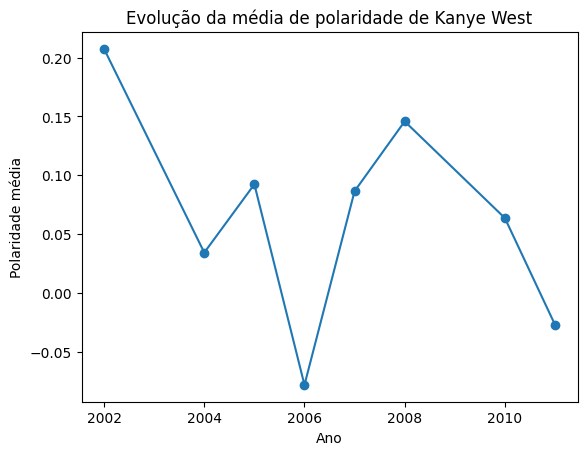

              artist  var_total
0              Spose   0.851122
1        Wyclef Jean   0.622917
2  The Lonely Island   0.591779
3      Missy Elliott   0.570321
4            Mac Dre   0.495746
5          Dj Khaled   0.486360
6                D12   0.458763
7             King T   0.446316
8  The Notorious BIG   0.428496
9       Beastie Boys   0.388665
Correlação polarity × views: -0.018


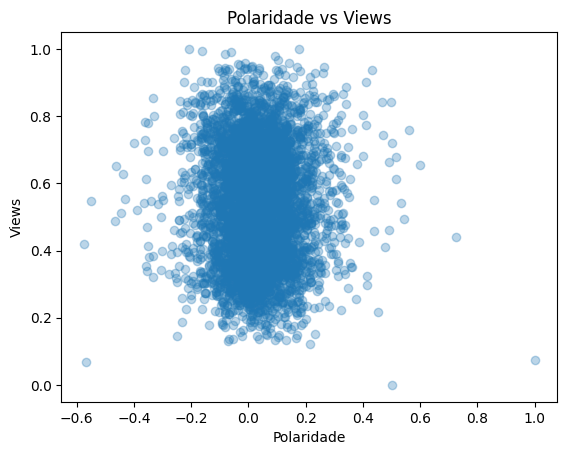

In [54]:
def categorize(p):
    if p <= -0.05:
        return 'negativo'
    elif p >= 0.05:
        return 'positivo'
    else:
        return 'neutro'

df_pred['sentimento'] = df_pred['polarity'].apply(categorize)

summary = (
    df_pred
    .groupby(['artist', 'year'])
    .agg(
        media_polarity = ('polarity', 'mean'),
        std_polarity   = ('polarity', 'std'),
        n_musicas      = ('polarity', 'size'),
        media_views    = ('views', 'mean')
    )
    .reset_index()
)

import matplotlib.pyplot as plt

art = 'Kanye West'

summary['year_real'] = (summary['year'] * (ano_max - ano_min) + ano_min).round().astype(int)
summary['year_real'] = summary['year_real'].round().astype(int)
sub = (
    summary[summary['artist'] == art]
    .groupby('year_real', as_index=False)
    .agg(media_polarity=('media_polarity', 'mean'))
)

plt.plot(sub['year_real'], sub['media_polarity'], marker='o')
plt.title(f"Evolução da média de polaridade de {art}")
plt.xlabel('Ano')
plt.ylabel('Polaridade média')
plt.show()

artist_var = (
    summary
    .groupby('artist')
    .agg(var_total = ('media_polarity', lambda x: x.max() - x.min()))
    .sort_values('var_total', ascending=False)
    .head(10)
    .reset_index()
)
print(artist_var)

corr = df_pred[['polarity', 'views']].corr().loc['polarity','views']
print(f"Correlação polarity × views: {corr:.3f}")

plt.scatter(df_pred['polarity'], df_pred['views'], alpha=0.3)
plt.title("Polaridade vs Views")
plt.xlabel("Polaridade")
plt.ylabel("Views")
plt.show()


In [55]:
artista = "Kanye West"

df_artista = df_pred[df_pred['artist'] == artista]

musica_max = df_artista.loc[df_artista['polarity'].idxmax()]

musica_min = df_artista.loc[df_artista['polarity'].idxmin()]

print(f"Música com maior polaridade para {artista}:")
print(f"Título: {musica_max['title']}")
print(f"Polaridade: {musica_max['polarity']}")
print(f"Letras:\n{musica_max['lyrics']}\n")

print(f"Música com menor polaridade para {artista}:")
print(f"Título: {musica_min['title']}")
print(f"Polaridade: {musica_min['polarity']}")
print(f"Letras:\n{musica_min['lyrics']}")


Música com maior polaridade para Kanye West:
Título: Amazing
Polaridade: 0.4679166666666671
Letras:
It's amazing, I'm the reason Everybody fired up this evening I'm exhausted, barely breathing Holding on to what I believe in No matter what, you'll never take that from me My reign is as far as your eyes can see, it's amazing So amazing, so amazing, so amazing, it's amazing So amazing, so amazing, so amazing, it's amazing I'm a monster, I'm a killer I know I'm wrong, yeah I'm a problem That'll never ever be solved And no matter what, you'll never take that from me My reign is as far as your eyes can see, it's amazing So amazing, so amazing, so amazing, it's amazing So amazing, so amazing, so amazing, it's amazing I'm a monster, I'm a maven I know this world is changing Never gave in, never gave up I'm the only thing I'm afraid of No matter what, you'll never take that from me My reign is as far as your eyes can see, it's amazing So amazing, so amazing, so amazing, it's amazing So amazing